In [668]:
import pandas as pd
import numpy as np
from rapidfuzz import process, fuzz, distance
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import random
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
import seaborn as sns
import scipy.stats as stats
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression, RFE
from scipy.stats import f_oneway
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, make_scorer, r2_score, mean_absolute_error
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
from sklearn.model_selection import train_test_split, KFold, RepeatedKFold
from sklearn.ensemble import RandomForestRegressor

# Preprocessing

#### Data Quality Assessment and Initial Observations

In [819]:
import os
os.getcwd()

'/Users/carlosamorim/ml2526'

In [672]:
RANDOM_SEED = 1907
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

##### Let's perform an initial analysis of the train dataset.

In [674]:
df=pd.read_csv("train.csv")
display(df)
og_df = df.copy()

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75968,37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0
75969,6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0
75970,54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0
75971,860,Audi,Q3,2015.0,12990,Manual,69072.0,iesel,125.0,60.100000,2.0,74.0,2.000000,0.0


##### There's a total of 14 columns, with one of them being a candidate to be a unique identifier for each row (**carID**), leaving us 13 features to work with.

In [676]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB


##### Datatypes seem to be A-OK, thus we are left with 4 categorical features: **Brand**, **model**, **transmission** and **fuelType**

##### and 10 numeric features: **cardID**, **year**, **price**, **mileage**, **tax**, **mpg**, **engineSize**, **paintQuality%**, **previousOwners** and **hasDamage**

In [678]:
df.describe()

,carID,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,75973.000000,74482.000000,75973.000000,74510.000000,68069.000000,68047.000000,74457.000000,74449.000000,74423.000000,74425.0
mean,37986.000000,2017.096611,16881.889553,23004.184088,120.329078,55.152666,1.660136,64.590667,1.994580,0.0
std,21931.660338,2.208704,9736.926322,22129.788366,65.521176,16.497837,0.573462,21.021065,1.472981,0.0
min,0.000000,1970.000000,450.000000,-58540.574478,-91.121630,-43.421768,-0.103493,1.638913,-2.345650,0.0
25%,18993.000000,2016.000000,10200.000000,7423.250000,125.000000,46.300000,1.200000,47.000000,1.000000,0.0
50%,37986.000000,2017.000000,14699.000000,17300.000000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,56979.000000,2019.000000,20950.000000,32427.500000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,75972.000000,2024.121759,159999.000000,323000.000000,580.000000,470.800000,6.600000,125.594308,6.258371,0.0


#### Preprocessing **cardID**

##### Now for us to be able to use **cardID** as a true unique identifier we must first make sure there are no duplicates:

In [681]:
df["carID"].duplicated().any()

False

##### Since there are no duplicates we can now define **cardID** as a true unique identifier.

In [683]:
def carID_como_index(df):
    df = df.copy()
    df = df.set_index("carID")
    return df

df=carID_como_index(df)
display(df)

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0
6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0
54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0


##### Let's assess feature values and counts and see if there's any work to be done here. Let's start with **Brand**

#### Preprocessing **Brand**

In [686]:
df["Brand"].unique()

array(['VW', 'Toyota', 'Audi', 'Ford', 'BMW', 'Skoda', 'Opel', 'Mercedes',
       'FOR', 'mercedes', 'Hyundai', 'w', 'ord', 'MW', 'bmw', nan,
       'yundai', 'BM', 'Toyot', 'udi', 'Ope', 'AUDI', 'V', 'opel', 'pel',
       'For', 'pe', 'Mercede', 'audi', 'MERCEDES', 'OPEL', 'koda', 'FORD',
       'Hyunda', 'W', 'Aud', 'vw', 'hyundai', 'skoda', 'ford', 'TOYOTA',
       'ercedes', 'oyota', 'toyota', 'SKODA', 'Skod', 'HYUNDAI', 'kod',
       'v', 'for', 'SKOD', 'aud', 'KODA', 'PEL', 'yunda', 'or', 'UDI',
       'OYOTA', 'HYUNDA', 'mw', 'OPE', 'mercede', 'ERCEDES', 'ercede',
       'TOYOT', 'MERCEDE', 'ORD', 'ud', 'ope', 'AUD', 'hyunda', 'skod',
       'toyot'], dtype=object)

##### Several values for the same brand although with some missing letters (e.g. 'Audi', 'Aud', 'udi', 'audi', 'AUD' and 'ud' could be considered as all being the same value: AUDI) and some nans.

In [688]:
df["Brand"].value_counts()

Brand
Ford        14808
Mercedes    10754
VW           9780
Opel         8645
BMW          6968
            ...  
kod             2
TOYOT           1
SKOD            1
skod            1
toyot           1
Name: count, Length: 72, dtype: int64

In [689]:
df[df["Brand"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
66591,NaN,T-Roc,2018.0,23000,Semi-Auto,584.0,Petrol,150.0,41.5,2.0,79.0,1.0,0.0
5034,NaN,A3,2016.0,11871,Manual,52519.0,Diesel,20.0,72.4,1.6,60.0,2.0,0.0
33153,NaN,I20,2020.0,13966,MANUAL,3500.0,Petrol,145.0,47.9,1.0,41.0,2.0,0.0
45338,NaN,CL Class,2020.0,54995,Semi-Auto,NaN,Petrol,145.0,33.2,2.0,61.0,4.0,0.0
66712,NaN,POLO,2016.0,8650,Manual,32800.0,Petrol,20.0,60.1,1.0,54.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72615,NaN,Golf,2015.0,11750,Manual,79000.0,Diesel,20.0,67.3,2.0,68.0,0.0,0.0
3436,NaN,Q5,2015.0,21995,Semi-Auto,18188.0,Diesel,200.0,47.1,2.0,84.0,3.0,0.0
7392,NaN,A5,2019.0,31490,Automatic,10.0,Petrol,145.0,39.8,2.0,70.0,1.0,0.0


##### ~1500 NaNs

##### To fix incorrect entries, we must define a method to be able to treat these values for **Brand** and have the correct single unique brand name.

To fix the inconsistent and misspelled values for Brand, we’ll define a function that uses fuzzy string matching to map incorrect entries to their correct versions.

The first helper function we’ll define is **HELPER_marca_correta()**, responsible for evaluating each brand value individually and correcting it if necessary. It first checks whether the brand value is valid (i.e., not NaN or empty) and then converts it to lowercase for comparison.

Using fuzzywuzzy **process.extractOne()** (which uses Levenshtein distance), we compare the given brand to the dictionary of valid brands (**valid_brands**) and returns the closest match, along with a similarity score.

If the similarity score exceeds a defined threshold, the brand value is replaced by the correct brand name. Otherwise, it remains unchanged.
The second function, **fuzzy_marcas()**, applies this logic to the entire dataset. It first defines a list of valid brands — in this case: VW, Toyota, Audi, Ford, BMW, Opel, Skoda, Mercedes, and Hyundai.

These are converted into a lowercase dictionary for matching, where each key-value pair ensures the final brand name retains its original capitalization.

Finally, **fuzzy_marcas()** applies **HELPER_marca_correta()** to every value in **Brand**, replacing incorrect or misspelled records with their correct forms. **The threshold parameter (threshold=50) controls how strict the matching is.**
A lower threshold (e.g. 50) allows more aggressive corrections, while a higher one (e.g. 80) ensures only very similar strings are replaced.

This process effectively normalizes **Brand**, e.g. consolidating entries such as 'Audi', 'Aud', 'udi', 'audi', 'AUD' and 'ud' into their correct standardized name, 'Audi'.

In [693]:
def HELPER_marca_correta(marca, marcas_dict, threshold):
    if not isinstance(marca, str) or marca.strip() == "":
        return marca

    marca_lower = marca.lower().strip()

    result = process.extractOne(
        marca_lower,
        marcas_dict.keys(),
        scorer=fuzz.token_sort_ratio
    )

    #Levenshtein distance via fuzz.token_sort_ratio, to find the closest valid brand name among the dictionary keys
    #result = (match, score, index)
    #ex: match = toyota, score = 94.5, index = 1 (qual das marcas no dicionário é mais semelhante)

    if result is None:
        return marca

    match_lower, score, _ = result
    return marcas_dict[match_lower] if score >= threshold else marca

def fuzzy_marcas(df, threshold=50):
    df=df.copy()

    valid_brands = ["VW", "Toyota", "Audi", "Ford", "BMW", "Opel", "Skoda", "Mercedes", "Hyundai"]
    brands_dict = {BRAND.lower(): BRAND for BRAND in valid_brands}

    df["Brand"] = df["Brand"].apply(lambda x: HELPER_marca_correta(x, brands_dict, threshold))
    return df

In [694]:
df=fuzzy_marcas(df)
df["Brand"].unique()

array(['VW', 'Toyota', 'Audi', 'Ford', 'BMW', 'Skoda', 'Opel', 'Mercedes',
       'Hyundai', nan], dtype=object)

Thus, the treatment via **HELPER_marca_corret()** was successfull, and we are now left with 9 true brand names and NaN's.

In [696]:
df["Brand"].value_counts()

Brand
Ford        16063
Mercedes    11674
VW          10385
Opel         9352
BMW          7392
Audi         7325
Toyota       4622
Skoda        4303
Hyundai      3336
Name: count, dtype: int64

Let's now move onto **model**.

#### Preprocessing **model**

In [699]:
df["model"].unique()

array([' Golf', ' Yaris', ' Q2', ' FIESTA', ' 2 Series', '3 Series',
       ' A3', ' Octavia', ' Passat', ' Focus', ' Insignia', ' A Clas',
       ' Q3', ' Fabia', ' A Class', ' Ka+', ' 3 Series', ' GLC Class',
       ' I30', ' C Class', ' Polo', ' E Class', ' C Clas', ' Q5', ' Up',
       ' Fiesta', ' C-HR', ' Mokka X', ' Corsa', ' Astra', ' TT',
       ' 5 Series', ' Aygo', ' 4 Series', ' SLK', ' Viva', ' T-Roc',
       'Focus', ' EcoSport', ' Tucson', ' EcoSpor', nan, ' X-CLASS',
       ' CL Class', ' IX20', ' i20', ' Rapid', ' a1', ' Auris', ' sharan',
       ' I20', ' Adam', ' X3', ' A8', ' GLS Class', ' B-MAX', ' A4',
       ' Kona', ' I10', ' A1', ' Mokka', ' fiesta', ' S-MAX', ' X2',
       ' Crossland X', ' Tiguan', ' A5', ' GLE Class', ' C CLASS',
       ' mokka x', ' Zafira', ' Ioniq', ' A6', ' Mondeo', ' Yeti Outdoor',
       ' X1', 'POLO', ' INSIGNIA', ' Scala', ' S Class', ' 1 Series',
       ' Kamiq', ' Kuga', ' Tourneo Connect', ' Q7', ' GLA Class',
       ' Arteon', ' 

In [700]:
len(df["model"].unique())

736

In [701]:
# group models by brand
grouped = df.groupby("Brand")["model"].value_counts()

display(grouped["Hyundai"])


model
 Tucson      821
 I10         671
 I30         352
 I20         307
 Kona        213
 Ioniq       185
 Santa Fe    135
 IX20        129
 I40          78
 IX35         74
 I800         72
 i10          20
 Tucso        18
 TUCSON       17
 tucson       16
 I1           15
Tucson        15
I10           13
 I3            9
 Santa F       8
 i30           8
 Ioni          7
 i20           7
 Getz          6
Ioniq          6
Kona           6
I20            5
I30            5
 I2            4
 SANTA FE      4
 I80           3
 IX2           3
 ix20          3
 kona          3
 santa fe      3
Santa Fe       3
 IONIQ         2
 KONA          2
 Kon           2
 ix35          2
IX20           2
IX35           2
 Accent        1
 KON           1
 TUCSO         1
 Terracan      1
 Veloste       1
 i40           1
 ioniq         1
I40            1
IONIQ          1
Tucso          1
Name: count, dtype: int64

In [702]:
# Obtained through meticulous ChatGPT prompt engineering

valid_models = {
    "Audi": [
        "A1", "A2", "A3", "A4", "A5", "A6", "A7", "A8",
        "Q2", "Q3", "Q5", "Q7", "Q8",
        "TT", "T", "R8",
        "S3", "S4", "S5", "S8",
        "RS3", "RS4", "RS5", "RS6",
        "SQ5", "SQ7"
    ],

    "Ford": [
        "FOCUS", "FIESTA", "MONDEO", "KA", "KA+", "FUSION",
        "KUGA", "ECOSPORT", "EDGE", "PUMA",
        "CMAX", "BMAX", "SMAX", "GALAXY",
        "GRANDCMAX", "TOURNEOCONNECT", "GRANDTOURNEOCONNECT", "TOURNEOCUSTOM",
        "MUSTANG", "RANGER", "ESCORT", "STREETKA"
    ],

    "Mercedes": [
        "ACLASS", "BCLASS", "CCLASS", "ECLASS", "SCLASS",
        "GLA", "GLB", "GLC", "GLE", "GLS", "GCLASS", "GLCLASS", "MCLASS",
        "CLA", "CLS", "SL", "SLK", "CLK",
        "VCLASS", "XCLASS", "CLC"
    ],

    "VW": [
        "GOLF", "POLO", "PASSAT", "JETTA", "ARTEON", "SCIROCCO", "BEETLE",
        "UP", "GOL", "FOX",
        "TIGUAN", "TIGUANALLSPACE", "TROC", "TCROSS", "TOUAREG",
        "TOURAN", "SHARAN", "CADDY", "CADDYMAXI", "CADDYMAXILIFE",
        "CARAVELLE", "CALIFORNIA", "SHUTTLE",
        "AMAROK", "GOLFSV", "CC"
    ],

    "Opel": [
        "CORSA", "ASTRA", "INSIGNIA", "VECTRA",
        "MOKKA", "MOKKAX", "CROSSLAND", "CROSSLANDX",
        "GRANDLAND", "GRANDLANDX", "ANTARA",
        "ZAFIRA", "ZAFIRATOURER", "MERIVA", "COMBOLIFE", "VIVARO",
        "ADAM", "AGILA", "VIVA",
        "TIGRA", "GTC", "CASCADA", "AMPERA"
    ],

    "BMW": [
        "1SERIES", "2SERIES", "3SERIES", "4SERIES",
        "5SERIES", "6SERIES", "7SERIES", "8SERIES",
        "X1", "X2", "X3", "X4", "X5", "X6", "X7",
        "M2", "M3", "M4", "M5", "M6",
        "Z3", "Z4",
        "I3", "I4", "I8"
    ],

    "Toyota": [
        "YARIS", "AYGO", "AURIS", "COROLLA", "AVENSIS", "CAMRY", "PRIUS",
        "CHR", "RAV4", "LANDCRUISER", "URBANCRUISER",
        "VERSO", "VERSOS", "PROACEVERSO",
        "HILUX", "GT86", "SUPRA", "IQ"
    ],

    "Skoda": [
        "FABIA", "OCTAVIA", "SUPERB", "RAPID", "SCALA",
        "KODIAQ", "KAROQ", "KAMIQ", "YETI", "YETIOUTDOOR",
        "CITIGO", "ROOMSTER"
    ],

    "Hyundai": [
        "I10", "I20", "I30", "I40", "ACCENT", "GETZ",
        "KONA", "TUCSON", "SANTAFE", "IX20", "IX35",
        "I800", "IONIQ", "VELOSTER", "TERRACAN"
    ]
}

We are now left with a dictionary with valid brand names and their corresponding valid model names.
Let's perform a similar treatment to the one applied to **Brand** to standardize entries for **model**.

In [704]:
def HELPER_normalize_models(df):
    df = df.copy()
    
    df["model"] = (
        df["model"]
        .astype(str)
        .str.upper()
        .str.replace("-", "", regex=False)       # remove hyphens
        .str.replace(r"\s+", "", regex=True)     # remove all whitespace
        .replace(["", "NAN", "NONE"], None)
    )
    return df

def HELPER_hybrid_scorer(a, b, **kwargs):
    #hibrido entre o método tokenizer e o levenshtein 
    lev = distance.Levenshtein.normalized_similarity(a, b)
    token = fuzz.token_sort_ratio(a, b) / 100
    return (0.7 * lev + 0.3 * token) * 100

def HELPER_modelo_correto(model, brand, valid_models_dict, threshold):
    if not model or model.strip() == "":
        return None

    if not brand:
        return model
    
    # Skip unknown brands
    if brand not in valid_models_dict:
        return model
    
    valid_list = valid_models_dict[brand]

    result = process.extractOne(model, valid_list, scorer=HELPER_hybrid_scorer)

    if result is None:
        return model    

    model_name, score, _ = result
    return model_name if score >= threshold else None

def fuzzy_modelos(df, valid_models_dict, threshold=30):
    df = HELPER_normalize_models(df)
    
    df["model"] = df.apply(
        lambda row: HELPER_modelo_correto(row["model"], row["Brand"], valid_models_dict, threshold),
        axis=1
    )
    return df

In [705]:
len(df["model"].unique())
df[df["model"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
30317,Ford,NaN,2019.0,9999,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0,0.0
28739,Ford,NaN,2015.0,7099,Manual,74176.0,Diesel,NaN,NaN,1.5,84.0,2.0,NaN
63868,Opel,NaN,2016.0,8695,Manual,39460.0,Petrol,125.0,50.4,1.4,99.0,1.0,0.0
18304,Ford,NaN,2016.0,9632,Manual,18814.0,Petrol,20.0,62.8,1.0,74.0,NaN,0.0
65285,Opel,NaN,2016.0,6999,Manual,45367.0,Petrol,30.0,55.4,1.4,41.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72991,VW,NaN,2018.0,17391,Manual,17987.0,Petrol,145.0,46.3,1.4,58.0,2.0,NaN
29299,Ford,NaN,2017.0,19289,anual,28492.0,Diesel,145.0,56.5,2.0,85.0,1.0,0.0
56250,Opel,NaN,2019.0,15495,Manual,3129.0,Petrol,145.0,39.2,1.4,49.0,0.0,NaN


In [706]:
unique_models_per_brand = df.groupby("Brand")["model"].nunique()
print(unique_models_per_brand)

Brand
Audi         62
BMW          91
Ford         92
Hyundai      52
Mercedes    103
Opel         90
Skoda        61
Toyota       68
VW          114
Name: model, dtype: int64


In [707]:
df=fuzzy_modelos(df, valid_models)
display(df[df["model"].isna()])

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
30317,Ford,None,2019.0,9999,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0,0.0
28739,Ford,None,2015.0,7099,Manual,74176.0,Diesel,NaN,NaN,1.5,84.0,2.0,NaN
63868,Opel,None,2016.0,8695,Manual,39460.0,Petrol,125.0,50.4,1.4,99.0,1.0,0.0
18304,Ford,None,2016.0,9632,Manual,18814.0,Petrol,20.0,62.8,1.0,74.0,NaN,0.0
65285,Opel,None,2016.0,6999,Manual,45367.0,Petrol,30.0,55.4,1.4,41.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72991,VW,None,2018.0,17391,Manual,17987.0,Petrol,145.0,46.3,1.4,58.0,2.0,NaN
29299,Ford,None,2017.0,19289,anual,28492.0,Diesel,145.0,56.5,2.0,85.0,1.0,0.0
56250,Opel,None,2019.0,15495,Manual,3129.0,Petrol,145.0,39.2,1.4,49.0,0.0,NaN


In [708]:
unique_models_per_brand = df.groupby("Brand")["model"].nunique()
print(unique_models_per_brand)

Brand
Audi        26
BMW         24
Ford        22
Hyundai     15
Mercedes    13
Opel        23
Skoda       12
Toyota      18
VW          26
Name: model, dtype: int64


To treat the records which have valid **model** names but 'None' has its **Brand** value, we can define a function to infer the **Brand** value via the corresponding measure of central tendency, in this case, the mode.

E.g. the case where a record has 'TROC' as a **model** value and 'None' as a **Brand** value, **inferir_marca_com_modelo(df, valid_moedels_dict)** will search in the dictionary **valid_models_dict** for the **models** and its corresponding **Brand** and fill in with the mode of that specific **model** (i.e. its true brand name), thus resulting in the imputation of 'VW'.

In [711]:
def inferir_marca_com_modelo(df, valid_models_dict):
    df = df.copy()

 # Build a mapping of models → their most frequent (mode) brand in the dataset
    model_to_brand = (
        df[df["Brand"].notna()]
        .groupby("model")["Brand"]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
        .to_dict()
    )

    df["Brand"] = df.apply(
    lambda row: (
        row["Brand"]
        if pd.notna(row["Brand"])
        else model_to_brand.get(row["model"], None)
    ),
    axis=1
    )

    return df


In [712]:
df[df["Brand"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
66591,NaN,TROC,2018.0,23000,Semi-Auto,584.0,Petrol,150.0,41.5,2.0,79.0,1.0,0.0
5034,NaN,A3,2016.0,11871,Manual,52519.0,Diesel,20.0,72.4,1.6,60.0,2.0,0.0
33153,NaN,I20,2020.0,13966,MANUAL,3500.0,Petrol,145.0,47.9,1.0,41.0,2.0,0.0
45338,NaN,CLCLASS,2020.0,54995,Semi-Auto,NaN,Petrol,145.0,33.2,2.0,61.0,4.0,0.0
66712,NaN,POLO,2016.0,8650,Manual,32800.0,Petrol,20.0,60.1,1.0,54.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72615,NaN,GOLF,2015.0,11750,Manual,79000.0,Diesel,20.0,67.3,2.0,68.0,0.0,0.0
3436,NaN,Q5,2015.0,21995,Semi-Auto,18188.0,Diesel,200.0,47.1,2.0,84.0,3.0,0.0
7392,NaN,A5,2019.0,31490,Automatic,10.0,Petrol,145.0,39.8,2.0,70.0,1.0,0.0


In [713]:
df=inferir_marca_com_modelo(df, valid_models)
df[df["Brand"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
45338,None,CLCLASS,2020.0,54995,Semi-Auto,NaN,Petrol,145.0,33.2,2.0,61.0,4.0,0.0
16342,None,None,2017.0,8600,MANUAL,28820.0,Diesel,0.0,74.4,1.5,NaN,0.0,0.0
38054,None,CLSCLASS,2018.0,31026,Automatic,17663.0,Diesel,145.0,48.7,2.9,94.0,0.0,0.0
12064,None,None,2018.0,21300,Automatic,11258.0,NaN,145.0,64.2,2.0,60.0,3.0,0.0
44351,None,None,2013.0,12990,Automatic,43000.0,Diesel,145.0,54.3,2.1,78.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68226,None,None,2017.0,10491,Manual,22211.0,Petrol,150.0,60.1,1.2,82.0,0.0,0.0
4703,None,None,2019.0,51990,Automatic,10.0,Petrol,NaN,30.4,2.9,54.0,1.0,0.0
41846,None,GLCCLASS,2019.0,31400,Semi-Auto,7670.0,Diesel,145.0,44.8,2.0,60.0,3.0,0.0


In [714]:
df=fuzzy_modelos(df, valid_models)
display(df[df["model"].isna()])

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
30317,Ford,None,2019.0,9999,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0,0.0
28739,Ford,None,2015.0,7099,Manual,74176.0,Diesel,NaN,NaN,1.5,84.0,2.0,NaN
63868,Opel,None,2016.0,8695,Manual,39460.0,Petrol,125.0,50.4,1.4,99.0,1.0,0.0
18304,Ford,None,2016.0,9632,Manual,18814.0,Petrol,20.0,62.8,1.0,74.0,NaN,0.0
65285,Opel,None,2016.0,6999,Manual,45367.0,Petrol,30.0,55.4,1.4,41.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72991,VW,None,2018.0,17391,Manual,17987.0,Petrol,145.0,46.3,1.4,58.0,2.0,NaN
29299,Ford,None,2017.0,19289,anual,28492.0,Diesel,145.0,56.5,2.0,85.0,1.0,0.0
56250,Opel,None,2019.0,15495,Manual,3129.0,Petrol,145.0,39.2,1.4,49.0,0.0,NaN


In [715]:
df

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
69512,VW,GOLF,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
53000,Toyota,YARIS,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
10062,BMW,2SERIES,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,2015.0,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0
6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0
54886,Toyota,AYGO,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0


#### Preprocessing **year**

In [717]:
df["year"].unique()

array([2016.        , 2019.        , 2018.        , 2014.        ,
       2017.        , 2020.        , 2013.        ,           nan,
       2015.        , 2023.36707842, 2011.        , 2012.        ,
       2023.1169636 , 2003.        , 2009.        , 2007.        ,
       2005.        , 2011.11118842, 2011.21085349, 2023.97731126,
       2004.        , 2010.        , 2010.56500919, 2008.        ,
       2024.12175905, 2006.        , 2023.60527574, 2023.38982198,
       2010.67696784, 2001.        , 2000.        , 2023.26798867,
       2010.26863473, 2010.37154646, 2002.        , 2022.69668507,
       2009.81675711, 2010.7464032 , 2012.69574039, 1996.        ,
       1998.        , 2022.87800554, 1970.        , 1999.        ,
       1997.        ])

In [718]:
df[df["year"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35263,Mercedes,CCLASS,NaN,11295,Automatic,45000.0,Petrol,-56.193202,46.3,1.6,59.0,NaN,0.0
68423,VW,POLO,NaN,10328,NaN,26941.0,Petrol,145.000000,60.1,1.2,97.0,4.0,0.0
49731,Skoda,OCTAVIA,NaN,11990,Manual,35650.0,NaN,30.000000,55.4,1.4,68.0,3.0,0.0
38604,Mercedes,ECLASS,NaN,34980,Semi-Auto,4196.0,diesel,145.000000,70.6,2.0,44.0,1.0,0.0
37812,Mercedes,ECLASS,NaN,17165,Automatic,36959.0,Diesel,150.000000,53.3,3.0,53.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67270,VW,POLO,NaN,6880,Semi-Auto,44551.0,etrol,145.000000,47.9,1.4,92.0,2.0,0.0
61087,Opel,None,NaN,14295,Manual,14609.0,Petrol,145.000000,39.2,1.4,50.0,2.0,0.0
62592,Opel,ASTRA,NaN,10295,Manual,10271.0,Petrol,145.000000,62.8,1.0,99.0,3.0,0.0


In [719]:
old_cars = df[df["year"] < 2000][["Brand", "model", "year"]]
display(old_cars)
#os carros de 1970 nem existiam em 1970

,Brand,model,year
carID,,,
25881,Ford,ESCORT,1996.0
3908,Audi,A3,1998.0
62732,Opel,ZAFIRA,1970.0
13422,BMW,Z3,1999.0
36128,Mercedes,SLK,1998.0
51800,Toyota,YARIS,1999.0
34918,Mercedes,SCLASS,1997.0
52914,Toyota,LANDCRUISER,1998.0
35769,Mercedes,MCLASS,1970.0


In [720]:
def limpar_anos(df):
    df = df.copy()

    df["year"] = np.round(df["year"]).astype("float")
    df.loc[(df["year"] < 1980) | (df["year"] > 2020),"year"] = np.nan
    df["year"] = df["year"].astype("Int64")
    return df

In [721]:
df = limpar_anos(df)
df[df["year"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35263,Mercedes,CCLASS,<NA>,11295,Automatic,45000.0,Petrol,-56.193202,46.3,1.6,59.0,NaN,0.0
53282,Toyota,YARIS,<NA>,16995,Manual,1225.0,Petrol,145.000000,47.9,1.5,77.0,0.0,0.0
68423,VW,POLO,<NA>,10328,NaN,26941.0,Petrol,145.000000,60.1,1.2,97.0,4.0,0.0
49731,Skoda,OCTAVIA,<NA>,11990,Manual,35650.0,NaN,30.000000,55.4,1.4,68.0,3.0,0.0
38604,Mercedes,ECLASS,<NA>,34980,Semi-Auto,4196.0,diesel,145.000000,70.6,2.0,44.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67270,VW,POLO,<NA>,6880,Semi-Auto,44551.0,etrol,145.000000,47.9,1.4,92.0,2.0,0.0
61087,Opel,None,<NA>,14295,Manual,14609.0,Petrol,145.000000,39.2,1.4,50.0,2.0,0.0
62592,Opel,ASTRA,<NA>,10295,Manual,10271.0,Petrol,145.000000,62.8,1.0,99.0,3.0,0.0


In [722]:
df["year"].unique()

<IntegerArray>
[2016, 2019, 2018, 2014, 2017, 2020, 2013, <NA>, 2015, 2011, 2012, 2003, 2009,
 2007, 2005, 2004, 2010, 2008, 2006, 2001, 2000, 2002, 1996, 1998, 1999, 1997]
Length: 26, dtype: Int64

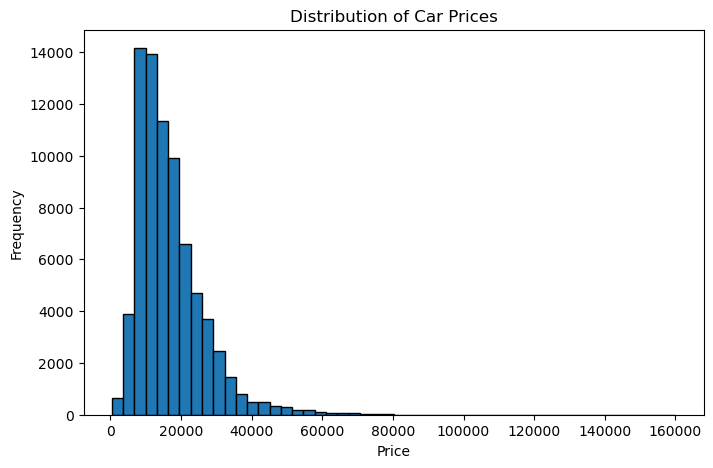

In [723]:
plt.figure(figsize=(8, 5))
plt.hist(df["price"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [724]:
df["price"].describe()

count     75973.000000
mean      16881.889553
std        9736.926322
min         450.000000
25%       10200.000000
50%       14699.000000
75%       20950.000000
max      159999.000000
Name: price, dtype: float64

In [725]:
ordenado = df.sort_values("price", ascending=True)

baratos = ordenado[["Brand", "model", "year", "price"]].head(5)
caros = baratos[["Brand", "model", "year", "price"]].tail(5)
display(baratos)
display(caros)
#acho possível estes carros em especifico terem estes preços

,Brand,model,year,price
carID,,,,
60156,Opel,AGILA,2003,450
23427,Ford,FOCUS,2003,495
61005,Opel,CORSA,2002,495
19562,Ford,FOCUS,2003,495
55950,Opel,CORSA,2003,590


,Brand,model,year,price
carID,,,,
60156,Opel,AGILA,2003,450
23427,Ford,FOCUS,2003,495
61005,Opel,CORSA,2002,495
19562,Ford,FOCUS,2003,495
55950,Opel,CORSA,2003,590


In [726]:
def preco_no_fim(df):
    df = df.copy()

    df = df[[col for col in df.columns if col != "price"] + ["price"]]
    return df

#### Preprocessing **transmission**

In [728]:
df["transmission"].unique()

array(['Semi-Auto', 'Manual', 'anual', 'Semi-Aut', 'Automatic', 'manual',
       nan, 'unknown', 'Manua', 'AUTOMATIC', 'MANUAL', 'semi-auto',
       ' Manual ', 'automatic', 'emi-Auto', 'SEMI-AUTO', 'SEMI-AUT',
       'Automati', 'ANUAL', 'utomatic', 'unknow', 'EMI-AUTO', 'manua',
       'anua', 'emi-Aut', 'MANUA', 'emi-auto', 'UTOMATIC', ' manual ',
       ' MANUAL ', 'UNKNOWN', 'nknown', 'automati', 'Other', 'semi-aut',
       ' Manual', 'AUTOMATI', 'utomati', 'Manual ', 'manual ', 'nknow'],
      dtype=object)

In [729]:
df[df["transmission"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35317,Mercedes,CCLASS,2019,26176,NaN,9463.0,Petrol,NaN,NaN,1.5,87.0,1.0,0.0
35376,Mercedes,CCLASS,2015,16998,NaN,43883.0,Diesel,125.0,60.1,2.1,54.0,0.0,0.0
64396,Opel,ASTRA,2015,6995,NaN,NaN,Diesel,0.0,78.5,1.6,61.0,2.0,0.0
68423,VW,POLO,<NA>,10328,NaN,26941.0,Petrol,145.0,60.1,1.2,97.0,4.0,0.0
47887,Skoda,FABIA,2020,11990,NaN,835.0,Petrol,145.0,47.1,1.0,55.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2368,Audi,Q2,2019,19990,NaN,1500.0,Petrol,145.0,47.1,1.0,92.0,2.0,0.0
12874,BMW,4SERIES,2019,29995,NaN,999.0,Diesel,145.0,53.3,3.0,64.0,0.0,0.0
1016,Audi,Q5,2016,22995,NaN,28000.0,Diesel,200.0,NaN,2.0,42.0,4.0,0.0


In [730]:
def HELPER_normalize_transmission(df):
    df = df.copy()
    df["transmission"] = (
        df["transmission"]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace(["", "NAN", "NONE"], np.nan)
    )
    return df

In [731]:
def HELPER_transmissao_correta(transm, valid_list, threshold):
    if pd.isna(transm):
        return np.nan

    if transm in valid_list:
        return transm
    
    result = process.extractOne(transm, valid_list, scorer=fuzz.token_sort_ratio)
    if result is None:
        return np.nan

    match_name, score, _ = result
    return match_name if score >= threshold else np.nan

def fuzzy_transmissao(df, threshold=60):
    df = HELPER_normalize_transmission(df)
    valid_list = ["MANUAL", "AUTOMATIC", "SEMI-AUTO", "OTHER", "UNKNOWN"]

    df["transmission"] = df["transmission"].apply(
        lambda x: HELPER_transmissao_correta(x, valid_list, threshold)
    )
    return df

In [732]:
df = fuzzy_transmissao(df)
df[df["transmission"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35317,Mercedes,CCLASS,2019,26176,NaN,9463.0,Petrol,NaN,NaN,1.5,87.0,1.0,0.0
35376,Mercedes,CCLASS,2015,16998,NaN,43883.0,Diesel,125.0,60.1,2.1,54.0,0.0,0.0
64396,Opel,ASTRA,2015,6995,NaN,NaN,Diesel,0.0,78.5,1.6,61.0,2.0,0.0
68423,VW,POLO,<NA>,10328,NaN,26941.0,Petrol,145.0,60.1,1.2,97.0,4.0,0.0
47887,Skoda,FABIA,2020,11990,NaN,835.0,Petrol,145.0,47.1,1.0,55.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2368,Audi,Q2,2019,19990,NaN,1500.0,Petrol,145.0,47.1,1.0,92.0,2.0,0.0
12874,BMW,4SERIES,2019,29995,NaN,999.0,Diesel,145.0,53.3,3.0,64.0,0.0,0.0
1016,Audi,Q5,2016,22995,NaN,28000.0,Diesel,200.0,NaN,2.0,42.0,4.0,0.0


In [733]:
df["transmission"].unique()

array(['SEMI-AUTO', 'MANUAL', 'AUTOMATIC', nan, 'UNKNOWN', 'OTHER'],
      dtype=object)

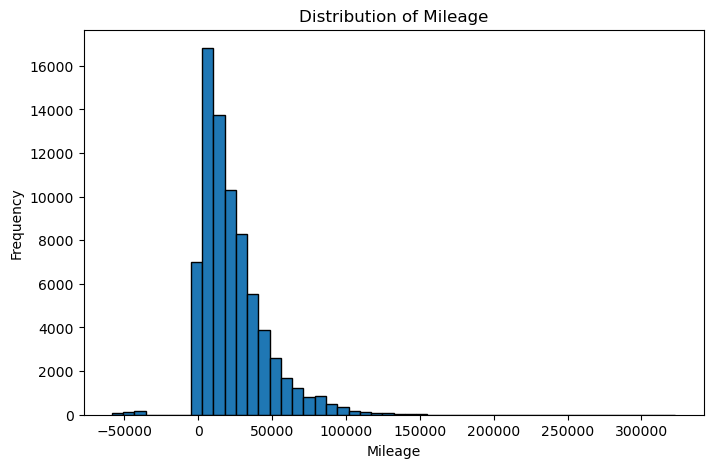

In [734]:
plt.figure(figsize=(8, 5))
plt.hist(df["mileage"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Mileage")
plt.xlabel("Mileage")
plt.ylabel("Frequency")
plt.show()

#### Preprocessing **mileage**

In [736]:
df[df["mileage"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
64396,Opel,ASTRA,2015,6995,NaN,NaN,Diesel,0.000000,78.5,1.6,61.0,2.0,0.0
41441,Mercedes,ACLASS,2017,13500,MANUAL,NaN,Diesel,150.000000,72.4,1.5,32.0,2.0,0.0
22269,Ford,FIESTA,2017,8930,NaN,NaN,Petrol,145.000000,54.3,1.2,97.0,0.0,0.0
6409,Audi,A1,2016,10999,MANUAL,NaN,Diesel,0.000000,76.3,1.6,97.0,3.0,0.0
7725,BMW,X2,2019,23633,MANUAL,NaN,Diesel,145.000000,53.3,2.0,97.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33828,Hyundai,TUCSON,2019,18390,MANUAL,NaN,Petrol,145.000000,34.9,1.6,86.0,4.0,0.0
55680,Toyota,CHR,2017,20700,AUTOMATIC,NaN,Hybrid,135.000000,74.3,1.8,86.0,0.0,0.0
39353,Mercedes,GLCLASS,2019,36490,SEMI-AUTO,NaN,Diesel,145.000000,40.9,2.0,36.0,3.0,0.0


In [737]:
df[df["mileage"] < 0]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
70615,VW,TIGUAN,2020,25000,MANUAL,-48190.655673,Petrol,145.0,38.2,1.5,89.0,3.0,0.0
43529,Mercedes,CCLASS,2019,25780,SEMI-AUTO,-50755.210230,Diesel,NaN,NaN,2.0,72.0,3.0,0.0
71090,VW,GOLF,2018,14995,MANUAL,-48190.655673,Diesel,150.0,57.7,1.6,83.0,2.0,0.0
7845,BMW,3SERIES,2019,23498,SEMI-AUTO,-58540.574478,Diesel,145.0,54.3,2.0,38.0,NaN,0.0
24999,Ford,FIESTA,2017,8895,MANUAL,-42650.453719,Petrol,125.0,54.3,1.2,45.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56373,Opel,None,2018,8514,MANUAL,-42707.564215,Petrol,150.0,55.4,1.4,49.0,1.0,NaN
45765,Mercedes,GLCLASS,2020,54995,AUTOMATIC,-50755.210230,Diesel,150.0,32.8,3.0,69.0,4.0,0.0
38413,Mercedes,SLK,2015,17900,AUTOMATIC,-50755.210230,Diesel,150.0,56.5,2.1,40.0,3.0,0.0


In [738]:
def impossible_to_nan(df, col, val=0, lower_upper="lower"):
    df=df.copy()

    if lower_upper=="lower":
        df.loc[df[col]<val, col] = np.nan
        return df
    else:
        df.loc[df[col]>val, col] = np.nan
        return df

In [739]:
df=impossible_to_nan(df, "mileage")
df.loc[70615]

Brand                 VW
model             TIGUAN
year                2020
price              25000
transmission      MANUAL
mileage              NaN
fuelType          Petrol
tax                145.0
mpg                 38.2
engineSize           1.5
paintQuality%       89.0
previousOwners       3.0
hasDamage            0.0
Name: 70615, dtype: object

In [740]:
df[df["mileage"] < 0]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,


In [741]:
df[df["mileage"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
64396,Opel,ASTRA,2015,6995,NaN,NaN,Diesel,0.000000,78.5,1.6,61.0,2.0,0.0
41441,Mercedes,ACLASS,2017,13500,MANUAL,NaN,Diesel,150.000000,72.4,1.5,32.0,2.0,0.0
22269,Ford,FIESTA,2017,8930,NaN,NaN,Petrol,145.000000,54.3,1.2,97.0,0.0,0.0
6409,Audi,A1,2016,10999,MANUAL,NaN,Diesel,0.000000,76.3,1.6,97.0,3.0,0.0
7725,BMW,X2,2019,23633,MANUAL,NaN,Diesel,145.000000,53.3,2.0,97.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39353,Mercedes,GLCLASS,2019,36490,SEMI-AUTO,NaN,Diesel,145.000000,40.9,2.0,36.0,3.0,0.0
9474,BMW,3SERIES,2016,14000,MANUAL,NaN,Diese,316.487189,62.8,2.0,77.0,4.0,0.0
55820,Toyota,AYGO,2019,8491,MANUAL,NaN,Petrol,145.000000,56.5,1.0,56.0,0.0,0.0


#### Preprocessing **fuelType**

In [821]:
df["fuelType"].unique()

array(['PETROL', 'DIESEL', 'HYBRID', nan, 'OTHER', 'ELECTRIC'],
      dtype=object)

In [823]:
df[df["fuelType"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
831,Audi,A8,2017,38995,AUTOMATIC,3338.0,NaN,145.0,NaN,3.0,84.000000,0.000000,0.0
49731,Skoda,OCTAVIA,<NA>,11990,MANUAL,35650.0,NaN,30.0,55.4,1.4,68.000000,3.000000,0.0
1272,Audi,Q7,2017,53990,SEMI-AUTO,30427.0,NaN,145.0,39.2,4.0,78.000000,1.000000,0.0
36753,Mercedes,SCLASS,2017,18990,AUTOMATIC,21490.0,NaN,145.0,70.6,2.1,84.000000,6.258371,0.0
53403,Toyota,AYGO,2016,7995,MANUAL,25300.0,NaN,0.0,69.0,1.0,125.594308,1.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48354,Skoda,OCTAVIA,2015,8599,MANUAL,57718.0,NaN,0.0,74.3,1.6,74.000000,3.000000,0.0
30306,Ford,FIESTA,2017,8499,MANUAL,18227.0,NaN,0.0,65.7,1.0,99.000000,4.000000,0.0
30535,Ford,FIESTA,2016,8990,MANUAL,46000.0,NaN,0.0,65.7,1.0,88.000000,2.000000,0.0


In [825]:
df["fuelType"].value_counts()

fuelType
PETROL      41181
DIESEL      30885
HYBRID       2225
OTHER         167
ELECTRIC        4
Name: count, dtype: int64

In [827]:
def HELPER_normalize_fueltype(df):
    df = df.copy()
    df["fuelType"] = (
        df["fuelType"]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace(["", "NAN", "NONE"], np.nan)
    )
    return df

In [829]:
def HELPER_fuel_correto(fuel, valid_list, threshold):
    if pd.isna(fuel):
        return np.nan

    if fuel in valid_list:
        return fuel
    
    result = process.extractOne(fuel, valid_list, scorer=fuzz.token_sort_ratio)
    if result is None:
        return np.nan

    match_name, score, _ = result
    return match_name if score >= threshold else np.nan

def fuzzy_fuel(df, threshold=60):
    df = HELPER_normalize_fueltype(df)
    valid_list = ["PETROL", "DIESEL", "HYBRID", "OTHER", "ELECTRIC"]

    df["fuelType"] = df["fuelType"].apply(
        lambda x: HELPER_fuel_correto(x, valid_list, threshold)
    )
    return df

In [831]:
df=fuzzy_fuel(df)
df["fuelType"].unique()

array(['PETROL', 'DIESEL', 'HYBRID', nan, 'OTHER', 'ELECTRIC'],
      dtype=object)

In [833]:
df[df["fuelType"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
831,Audi,A8,2017,38995,AUTOMATIC,3338.0,NaN,145.0,NaN,3.0,84.000000,0.000000,0.0
49731,Skoda,OCTAVIA,<NA>,11990,MANUAL,35650.0,NaN,30.0,55.4,1.4,68.000000,3.000000,0.0
1272,Audi,Q7,2017,53990,SEMI-AUTO,30427.0,NaN,145.0,39.2,4.0,78.000000,1.000000,0.0
36753,Mercedes,SCLASS,2017,18990,AUTOMATIC,21490.0,NaN,145.0,70.6,2.1,84.000000,6.258371,0.0
53403,Toyota,AYGO,2016,7995,MANUAL,25300.0,NaN,0.0,69.0,1.0,125.594308,1.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48354,Skoda,OCTAVIA,2015,8599,MANUAL,57718.0,NaN,0.0,74.3,1.6,74.000000,3.000000,0.0
30306,Ford,FIESTA,2017,8499,MANUAL,18227.0,NaN,0.0,65.7,1.0,99.000000,4.000000,0.0
30535,Ford,FIESTA,2016,8990,MANUAL,46000.0,NaN,0.0,65.7,1.0,88.000000,2.000000,0.0


In [836]:
df["fuelType"].value_counts()

fuelType
PETROL      41181
DIESEL      30885
HYBRID       2225
OTHER         167
ELECTRIC        4
Name: count, dtype: int64

#### Preprocessing **tax**

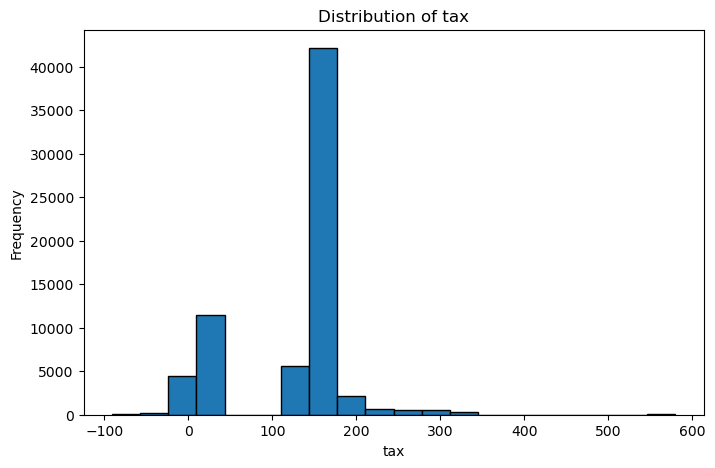

In [517]:
plt.figure(figsize=(8, 5))
plt.hist(df["tax"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of tax")
plt.xlabel("tax")
plt.ylabel("Frequency")
plt.show()

In [518]:
df[df["tax"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
69512,VW,GOLF,2016,22290,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4.0,0.0
20142,Ford,FOCUS,2017,18997,MANUAL,20112.0,PETROL,NaN,NaN,2.0,40.0,4.0,0.0
39796,Mercedes,CCLASS,2019,31299,SEMI-AUTO,1000.0,DIESEL,NaN,NaN,2.0,33.0,4.0,0.0
35317,Mercedes,CCLASS,2019,26176,NaN,9463.0,PETROL,NaN,NaN,1.5,87.0,1.0,0.0
35004,Mercedes,CCLASS,2016,21499,AUTOMATIC,26741.0,DIESEL,NaN,NaN,2.1,80.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24300,Ford,FOCUS,2017,17000,MANUAL,26041.0,DIESEL,NaN,NaN,2.0,39.0,3.0,0.0
40757,Mercedes,CCLASS,2019,28980,AUTOMATIC,8501.0,DIESEL,NaN,NaN,2.0,97.0,3.0,0.0
19457,Ford,FOCUS,2019,18910,MANUAL,11167.0,PETROL,NaN,NaN,1.0,30.0,4.0,0.0


In [519]:
def impossible_to_nan(df, col, val=0, lower_upper="lower"):
    df=df.copy()

    if lower_upper=="lower":
        df.loc[df[col]<val, col] = np.nan
        return df
    else:
        df.loc[df[col]>val, col] = np.nan
        return df

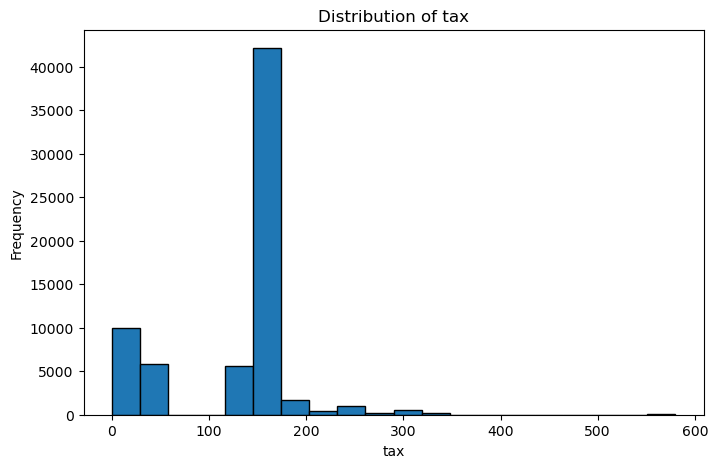

In [520]:
df=impossible_to_nan(df, "tax")

plt.figure(figsize=(8, 5))
plt.hist(df["tax"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of tax")
plt.xlabel("tax")
plt.ylabel("Frequency")
plt.show()

In [521]:
df[df["tax"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
69512,VW,GOLF,2016,22290,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4.0,0.0
20142,Ford,FOCUS,2017,18997,MANUAL,20112.0,PETROL,NaN,NaN,2.0,40.0,4.0,0.0
39796,Mercedes,CCLASS,2019,31299,SEMI-AUTO,1000.0,DIESEL,NaN,NaN,2.0,33.0,4.0,0.0
35317,Mercedes,CCLASS,2019,26176,NaN,9463.0,PETROL,NaN,NaN,1.5,87.0,1.0,0.0
35263,Mercedes,CCLASS,<NA>,11295,AUTOMATIC,45000.0,PETROL,NaN,46.300000,1.6,59.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24300,Ford,FOCUS,2017,17000,MANUAL,26041.0,DIESEL,NaN,NaN,2.0,39.0,3.0,0.0
40757,Mercedes,CCLASS,2019,28980,AUTOMATIC,8501.0,DIESEL,NaN,NaN,2.0,97.0,3.0,0.0
19457,Ford,FOCUS,2019,18910,MANUAL,11167.0,PETROL,NaN,NaN,1.0,30.0,4.0,0.0


In [522]:
g = df[df["tax"] == 0]
g["year"].value_counts()

year
2016    1675
2017    1046
2015     827
2014     391
2013     221
2012      26
2011      16
2010      15
2009       5
2018       2
Name: count, dtype: Int64

#### Preprocessing **mpg**

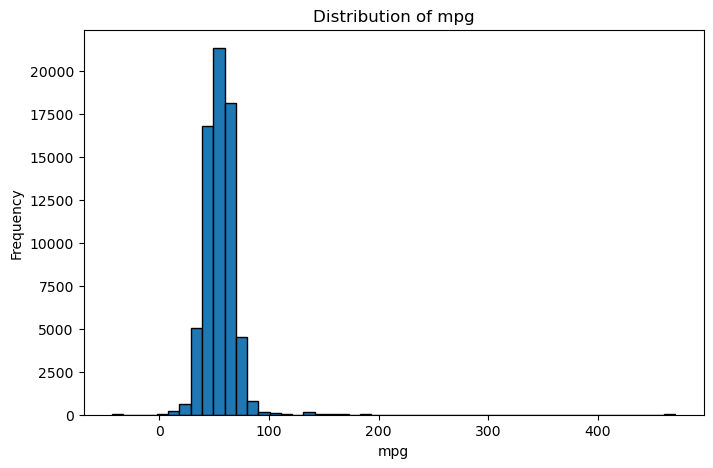

In [524]:
plt.figure(figsize=(8, 5))
plt.hist(df["mpg"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of mpg")
plt.xlabel("mpg")
plt.ylabel("Frequency")
plt.show()
#FIXE

In [525]:
df[df["mpg"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
20142,Ford,FOCUS,2017,18997,MANUAL,20112.0,PETROL,NaN,NaN,2.0,40.0,4.0,0.0
39796,Mercedes,CCLASS,2019,31299,SEMI-AUTO,1000.0,DIESEL,NaN,NaN,2.0,33.0,4.0,0.0
35317,Mercedes,CCLASS,2019,26176,NaN,9463.0,PETROL,NaN,NaN,1.5,87.0,1.0,0.0
35004,Mercedes,CCLASS,2016,21499,AUTOMATIC,26741.0,DIESEL,NaN,NaN,2.1,80.0,1.0,0.0
19811,Ford,FOCUS,2019,17990,AUTOMATIC,3289.0,DIESEL,NaN,NaN,1.5,38.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24300,Ford,FOCUS,2017,17000,MANUAL,26041.0,DIESEL,NaN,NaN,2.0,39.0,3.0,0.0
1016,Audi,Q5,2016,22995,NaN,28000.0,DIESEL,200.0,NaN,2.0,42.0,4.0,0.0
40757,Mercedes,CCLASS,2019,28980,AUTOMATIC,8501.0,DIESEL,NaN,NaN,2.0,97.0,3.0,0.0


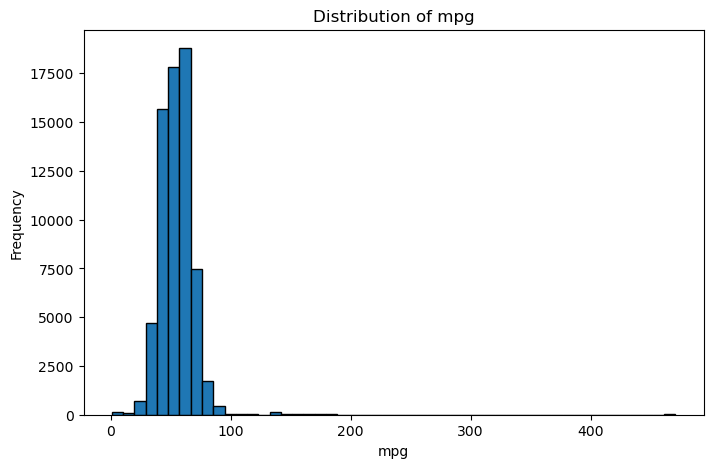

In [526]:
df=impossible_to_nan(df, "mpg")

plt.figure(figsize=(8, 5))
plt.hist(df["mpg"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of mpg")
plt.xlabel("mpg")
plt.ylabel("Frequency")
plt.show()

In [527]:
df[df["mpg"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
20142,Ford,FOCUS,2017,18997,MANUAL,20112.0,PETROL,NaN,NaN,2.0,40.0,4.0,0.0
39796,Mercedes,CCLASS,2019,31299,SEMI-AUTO,1000.0,DIESEL,NaN,NaN,2.0,33.0,4.0,0.0
35317,Mercedes,CCLASS,2019,26176,NaN,9463.0,PETROL,NaN,NaN,1.5,87.0,1.0,0.0
35004,Mercedes,CCLASS,2016,21499,AUTOMATIC,26741.0,DIESEL,NaN,NaN,2.1,80.0,1.0,0.0
19811,Ford,FOCUS,2019,17990,AUTOMATIC,3289.0,DIESEL,NaN,NaN,1.5,38.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24300,Ford,FOCUS,2017,17000,MANUAL,26041.0,DIESEL,NaN,NaN,2.0,39.0,3.0,0.0
1016,Audi,Q5,2016,22995,NaN,28000.0,DIESEL,200.0,NaN,2.0,42.0,4.0,0.0
40757,Mercedes,CCLASS,2019,28980,AUTOMATIC,8501.0,DIESEL,NaN,NaN,2.0,97.0,3.0,0.0


#### Preprocessing **engineSize**

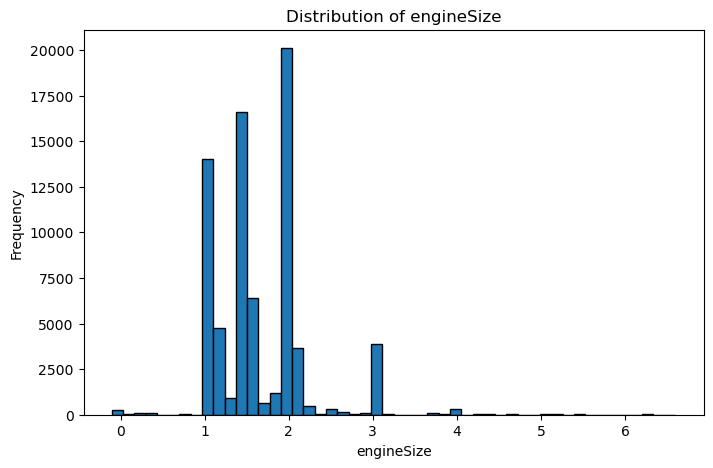

In [529]:
plt.figure(figsize=(8, 5))
plt.hist(df["engineSize"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of engineSize")
plt.xlabel("engineSize")
plt.ylabel("Frequency")
plt.show()

In [530]:
df[df["engineSize"] < 0.6]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
30317,Ford,None,2019,9999,MANUAL,10000.0,PETROL,145.0,47.9,0.000000,61.0,3.0,0.0
24113,Ford,KUGA,<NA>,14950,MANUAL,13411.0,DIESEL,125.0,60.1,-0.103493,83.0,1.0,0.0
3840,Audi,None,2019,21262,MANUAL,4868.0,DIESEL,145.0,49.6,0.154529,58.0,2.0,0.0
21935,Ford,KA,2018,8444,MANUAL,17000.0,PETROL,145.0,57.7,0.000000,51.0,0.0,0.0
9518,BMW,2SERIES,2015,14700,AUTOMATIC,32882.0,DIESEL,125.0,60.1,0.000000,55.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33307,Hyundai,I10,2018,8500,MANUAL,12948.0,PETROL,145.0,60.1,0.000000,46.0,2.0,0.0
46732,Skoda,OCTAVIA,2018,11290,MANUAL,20047.0,PETROL,145.0,58.9,0.191462,98.0,0.0,0.0
38494,Mercedes,GLCLASS,2016,19498,SEMI-AUTO,27846.0,DIESEL,125.0,56.5,0.307074,89.0,4.0,0.0


In [531]:
df[df["engineSize"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
48622,Skoda,FABIA,2019,13295,AUTOMATIC,14378.0,PETROL,145.0,60.1,NaN,59.0,1.0,0.0
38898,Mercedes,GLCLASS,2017,28995,AUTOMATIC,30808.0,DIESEL,150.0,56.5,NaN,60.0,1.0,0.0
54844,Toyota,AYGO,2017,7299,MANUAL,48238.0,PETROL,0.0,68.9,NaN,80.0,0.0,0.0
57086,Opel,INSIGNIA,2017,7695,MANUAL,51840.0,DIESEL,0.0,74.3,NaN,76.0,2.0,0.0
70418,VW,GOLF,2016,16898,MANUAL,24180.0,DIESEL,20.0,67.3,NaN,83.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68840,VW,POLO,2019,14999,MANUAL,4436.0,PETROL,150.0,52.3,NaN,98.0,2.0,0.0
61373,Opel,ASTRA,2017,10800,MANUAL,19025.0,PETROL,125.0,50.4,NaN,36.0,0.0,0.0
68148,VW,GOLF,2020,20769,MANUAL,1116.0,PETROL,145.0,49.6,NaN,86.0,4.0,0.0


In [532]:
df=impossible_to_nan(df, "engineSize", 0.6)
df[df["engineSize"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
48622,Skoda,FABIA,2019,13295,AUTOMATIC,14378.0,PETROL,145.0,60.1,NaN,59.0,1.0,0.0
38898,Mercedes,GLCLASS,2017,28995,AUTOMATIC,30808.0,DIESEL,150.0,56.5,NaN,60.0,1.0,0.0
30317,Ford,None,2019,9999,MANUAL,10000.0,PETROL,145.0,47.9,NaN,61.0,3.0,0.0
54844,Toyota,AYGO,2017,7299,MANUAL,48238.0,PETROL,0.0,68.9,NaN,80.0,0.0,0.0
57086,Opel,INSIGNIA,2017,7695,MANUAL,51840.0,DIESEL,0.0,74.3,NaN,76.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70592,VW,CADDYMAXI,2015,9995,SEMI-AUTO,66000.0,DIESEL,200.0,48.7,NaN,34.0,3.0,0.0
68148,VW,GOLF,2020,20769,MANUAL,1116.0,PETROL,145.0,49.6,NaN,86.0,4.0,0.0
10627,BMW,3SERIES,2020,24990,SEMI-AUTO,22.0,DIESEL,150.0,54.3,NaN,90.0,1.0,0.0


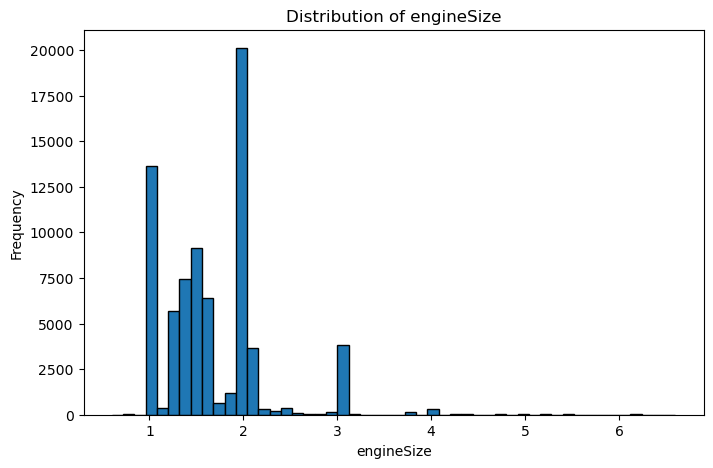

In [533]:
plt.figure(figsize=(8, 5))
plt.hist(df["engineSize"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of engineSize")
plt.xlabel("engineSize")
plt.ylabel("Frequency")
plt.show()

#### Preprocessing **paintQuality%**

In [535]:
df["paintQuality%"].describe()

count    74449.000000
mean        64.590667
std         21.021065
min          1.638913
25%         47.000000
50%         65.000000
75%         82.000000
max        125.594308
Name: paintQuality%, dtype: float64

In [536]:
df[df["paintQuality%"] > 100]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
15717,Ford,FIESTA,2018,10491,MANUAL,6522.0,PETROL,145.0,65.7,1.0,125.109951,3.0,0.0
11200,BMW,4SERIES,2019,23591,SEMI-AUTO,6100.0,PETROL,145.0,45.6,2.0,125.569499,2.0,0.0
53403,Toyota,AYGO,2016,7995,MANUAL,25300.0,NaN,0.0,69.0,1.0,125.594308,1.0,0.0
48038,Skoda,YETIOUTDOOR,2015,11995,SEMI-AUTO,19805.0,PETROL,125.0,51.4,1.2,125.453599,1.0,0.0
10137,BMW,5SERIES,2017,21995,AUTOMATIC,18820.0,DIESEL,145.0,65.7,2.0,125.569499,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75768,VW,TIGUAN,2018,18499,MANUAL,24940.0,PETROL,145.0,48.7,1.4,125.366507,0.0,0.0
39666,Mercedes,ECLASS,2017,21602,SEMI-AUTO,40690.0,DIESEL,145.0,NaN,3.0,125.202033,3.0,0.0
23930,Ford,FIESTA,2020,15000,MANUAL,35.0,PETROL,145.0,56.5,1.0,125.109951,0.0,0.0


In [537]:
df[df["paintQuality%"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
47148,Skoda,RAPID,2016,7991,MANUAL,33395.0,DIESEL,0.0,67.3,1.6,NaN,3.0,0.0
25484,Ford,BMAX,2016,9498,MANUAL,14853.0,DIESEL,0.0,74.4,1.5,NaN,1.0,0.0
41801,Mercedes,CCLASS,2019,49499,SEMI-AUTO,1000.0,PETROL,145.0,29.1,3.0,NaN,2.0,0.0
55579,Toyota,YARIS,2019,11280,MANUAL,6065.0,PETROL,145.0,47.9,1.5,NaN,0.0,0.0
55572,Toyota,AYGO,2019,10195,MANUAL,2114.0,PETROL,145.0,57.7,1.0,NaN,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26105,Ford,FOCUS,2013,6698,SEMI-AUTO,32685.0,PETROL,160.0,44.1,1.6,NaN,0.0,0.0
62623,Opel,MOKKAX,2019,14995,MANUAL,10.0,PETROL,145.0,39.2,1.4,NaN,0.0,NaN
64505,Opel,CORSA,2016,6999,MANUAL,13046.0,PETROL,30.0,55.4,1.4,NaN,0.0,0.0


In [538]:
df = impossible_to_nan(df,"paintQuality%", 100, "upper")
df[df["paintQuality%"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
47148,Skoda,RAPID,2016,7991,MANUAL,33395.0,DIESEL,0.0,67.3,1.6,NaN,3.0,0.0
25484,Ford,BMAX,2016,9498,MANUAL,14853.0,DIESEL,0.0,74.4,1.5,NaN,1.0,0.0
41801,Mercedes,CCLASS,2019,49499,SEMI-AUTO,1000.0,PETROL,145.0,29.1,3.0,NaN,2.0,0.0
55579,Toyota,YARIS,2019,11280,MANUAL,6065.0,PETROL,145.0,47.9,1.5,NaN,0.0,0.0
55572,Toyota,AYGO,2019,10195,MANUAL,2114.0,PETROL,145.0,57.7,1.0,NaN,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26105,Ford,FOCUS,2013,6698,SEMI-AUTO,32685.0,PETROL,160.0,44.1,1.6,NaN,0.0,0.0
62623,Opel,MOKKAX,2019,14995,MANUAL,10.0,PETROL,145.0,39.2,1.4,NaN,0.0,NaN
64505,Opel,CORSA,2016,6999,MANUAL,13046.0,PETROL,30.0,55.4,1.4,NaN,0.0,0.0


In [539]:
df["paintQuality%"].describe()

count    74082.000000
mean        64.290118
std         20.633703
min          1.638913
25%         47.000000
50%         64.000000
75%         82.000000
max         99.000000
Name: paintQuality%, dtype: float64

#### Preprocessing **previousOwners**

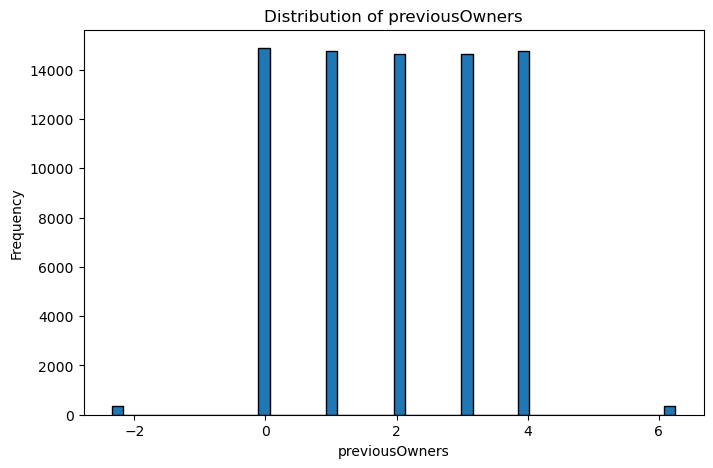

In [541]:
plt.figure(figsize=(8, 5))
plt.hist(df["previousOwners"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of previousOwners")
plt.xlabel("previousOwners")
plt.ylabel("Frequency")
plt.show()

In [542]:
df["previousOwners"].unique()

array([ 4.        ,  1.        , -2.34030622,  3.        ,  0.        ,
        2.        ,         nan, -2.34565   ,  6.25837066, -2.33512284,
        6.22789796,  6.25823052,  6.23017958, -2.33936045,  6.21772443,
        6.24583495, -2.29943868, -2.34010209, -2.31225953,  6.2482512 ,
       -2.31733109,  6.23308217,  6.24177863, -2.33744529])

In [543]:
df[df["previousOwners"]<0]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
29021,Ford,FIESTA,2018,12500,MANUAL,9102.0,PETROL,145.0,65.7,1.0,50.0,-2.340306,0.0
71677,VW,TIGUAN,2019,29999,SEMI-AUTO,669.0,DIESEL,145.0,39.8,2.0,42.0,-2.345650,0.0
16962,Ford,FOCUS,2019,19950,AUTOMATIC,7142.0,DIESEL,NaN,NaN,2.0,41.0,-2.340306,0.0
5994,Audi,None,2020,31990,SEMI-AUTO,4432.0,PETROL,150.0,40.4,1.5,98.0,-2.335123,0.0
5038,Audi,RS6,2020,97500,SEMI-AUTO,3220.0,PETROL,150.0,22.1,4.0,72.0,-2.335123,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67526,VW,PASSAT,2020,20998,SEMI-AUTO,15.0,DIESEL,145.0,49.6,1.6,62.0,-2.345650,0.0
75599,VW,UP,2015,6795,MANUAL,10800.0,PETROL,20.0,61.4,1.0,31.0,-2.345650,0.0
28295,Ford,SMAX,2017,17950,MANUAL,28280.0,PETROL,145.0,43.5,1.5,45.0,-2.340306,0.0


In [544]:
df[df["previousOwners"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35263,Mercedes,CCLASS,<NA>,11295,AUTOMATIC,45000.0,PETROL,NaN,46.3,1.6,59.0,NaN,0.0
18304,Ford,None,2016,9632,MANUAL,18814.0,PETROL,20.0,62.8,1.0,74.0,NaN,0.0
49135,Skoda,SCALA,2020,17000,MANUAL,731.0,PETROL,150.0,50.4,1.0,88.0,NaN,0.0
37446,Mercedes,CCLASS,2019,27099,SEMI-AUTO,1059.0,PETROL,145.0,45.6,1.5,87.0,NaN,0.0
1768,Audi,Q3,2020,35990,SEMI-AUTO,6000.0,DIESEL,145.0,47.1,2.0,48.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,Audi,A7,2014,19499,AUTOMATIC,47317.0,DIESEL,145.0,54.3,3.0,57.0,NaN,0.0
6295,Audi,A3,2018,17650,MANUAL,6350.0,PETROL,150.0,55.4,1.5,60.0,NaN,0.0
21918,Ford,FIESTA,2019,13998,MANUAL,10576.0,PETROL,145.0,58.9,1.0,65.0,NaN,0.0


In [545]:
def round_owners_int(df):
    df=df.copy()
    df["previousOwners"] = pd.to_numeric(df["previousOwners"], errors="coerce")

    df['previousOwners'] = df['previousOwners'].round().astype('Int64')
    return df

In [546]:
df=impossible_to_nan(df,"previousOwners")
df=round_owners_int(df)
df["previousOwners"].unique()

<IntegerArray>
[4, 1, <NA>, 3, 0, 2, 6]
Length: 7, dtype: Int64

#### Preprocessing **hasDamage**

In [548]:
df["hasDamage"].unique() #está cheia de zeros

array([ 0., nan])

In [549]:
def remove_hasdmg(df):
    df = df.copy()

    df = df.drop(columns=['hasDamage'])
    return df

In [550]:
df=remove_hasdmg(df)

In [551]:
display(df)

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,,
69512,VW,GOLF,2016,22290,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4
53000,Toyota,YARIS,2019,13790,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,50.0,1
6366,Audi,Q2,2019,24990,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,56.0,4
29021,Ford,FIESTA,2018,12500,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,50.0,<NA>
10062,BMW,2SERIES,2019,22995,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,97.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,2015,13498,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,78.0,0
6265,Audi,Q3,2013,12495,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,38.0,2
54886,Toyota,AYGO,2017,8399,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,57.0,3


In [552]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': (missing / len(df)) * 100
})

# Display the result
print("Missing Values with Percentage:\n")
print(missing_df)



Missing Values with Percentage:

                Missing Count  Missing Percentage
tax                      8282           10.901241
mpg                      7962           10.480039
engineSize               2034            2.677267
previousOwners           1921            2.528530
paintQuality%            1891            2.489042
year                     1851            2.436392
mileage                  1832            2.411383
transmission             1522            2.003343
model                    1520            2.000711
fuelType                 1511            1.988864
Brand                     104            0.136891


In [553]:
def fill_cats_UNKNOWN(df, cats):
    df = df.copy()
    for column in cats:
        df[column] = df[column].fillna('UNKNOWN')
    
    return df

In [554]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']
cat_cols = ['Brand', 'model', 'transmission', 'fuelType']
int_cols = ['year', 'previousOwners']
float_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%']   

In [555]:
df=fill_cats_UNKNOWN(df, cat_cols)

In [556]:
def clean_df(df, valid_models):
    df=df.copy()

    df=carID_como_index(df)
    df=fuzzy_marcas(df)
    df=fuzzy_modelos(df, valid_models)
    df=inferir_marca_com_modelo(df, valid_models)
    df=limpar_anos(df)
    df=fuzzy_transmissao(df)
    df=impossible_to_nan(df, "mileage")
    df=fuzzy_fuel(df)
    df=impossible_to_nan(df, "tax")
    df=impossible_to_nan(df, "mpg")
    df=impossible_to_nan(df, "engineSize", 0.49)
    df=impossible_to_nan(df,"paintQuality%", 100, "upper")
    df=impossible_to_nan(df,"previousOwners")
    df=round_owners_int(df)
    df=remove_hasdmg(df)
    df=fill_cats_UNKNOWN(df,cat_cols)
    
    return df

In [557]:
og_df=clean_df(og_df, valid_models)

In [659]:
assert pd.testing.assert_frame_equal(df, og_df) is None

#### Preprocessing **price**

Separate **price** from **df**

In [334]:
def separar_y(df):
    df=df.copy()

    X = df.drop('price', axis = 1)
    y = df['price']

    return X, y

In [336]:
X, y = separar_y(df)
X

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,
69512,VW,GOLF,2016,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4
53000,Toyota,YARIS,2019,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,50.0,1
6366,Audi,Q2,2019,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,56.0,4
29021,Ford,FIESTA,2018,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,50.0,<NA>
10062,BMW,2SERIES,2019,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,97.0,3
...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,2015,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,78.0,0
6265,Audi,Q3,2013,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,38.0,2
54886,Toyota,AYGO,2017,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,57.0,3


In [340]:
y

carID
69512    22290
53000    13790
6366     24990
29021    12500
10062    22995
         ...  
37194    13498
6265     12495
54886     8399
860      12990
15795    10495
Name: price, Length: 75973, dtype: int64

# Feature Selection

In [342]:
X_train, X_val, y_train, y_val = train_test_split(X,y, test_size = 0.3, random_state = RANDOM_SEED, shuffle = True)

In [344]:
df.dtypes

Brand              object
model              object
year                Int64
price               int64
transmission       object
mileage           float64
fuelType           object
tax               float64
mpg               float64
engineSize        float64
paintQuality%     float64
previousOwners      Int64
dtype: object

In [346]:
def fill_nans(X, ints, floats, fill_values=None):
    X = X.copy()

    if fill_values is None:
        fill_values = {"float": {}, "int": {}}
        for column in floats:
            mean_to_fill = X[column].mean()
            X[column] = X[column].fillna(mean_to_fill)
            fill_values["float"][column] = mean_to_fill
    
        for column in ints:
            median_to_fill = X[column].median()
            X[column] = X[column].fillna(median_to_fill).astype("Int64")
            fill_values["int"][column] = median_to_fill

        return X, fill_values
    else:
        for col in floats:
            X[col] = X[col].fillna(fill_values["float"][col])
        for col in ints:
            X[col] = X[col].fillna(fill_values["int"][col]).astype("Int64")

        return X

In [348]:
X_train, fill_values = fill_nans(X_train, int_cols, float_cols)
X_val = fill_nans(X_val, int_cols, float_cols, fill_values)

In [350]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53181 entries, 39423 to 35376
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           53181 non-null  object 
 1   model           53181 non-null  object 
 2   year            53181 non-null  Int64  
 3   transmission    53181 non-null  object 
 4   mileage         53181 non-null  float64
 5   fuelType        53181 non-null  object 
 6   tax             53181 non-null  float64
 7   mpg             53181 non-null  float64
 8   engineSize      53181 non-null  float64
 9   paintQuality%   53181 non-null  float64
 10  previousOwners  53181 non-null  Int64  
dtypes: Int64(2), float64(5), object(4)
memory usage: 5.0+ MB


In [352]:
def plot_nums(X, num_cols):
    for col in num_cols:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        fig.suptitle(col, fontsize=14, fontweight='bold')

        # Boxplot
        sns.boxplot(y=X[col], ax=axes[0], color='skyblue')
        axes[0].set_title("Boxplot")

        # Histogram
        sns.histplot(X[col], kde=True, ax=axes[1], color='salmon')
        axes[1].set_title("Histogram")

        plt.tight_layout()
        plt.show()

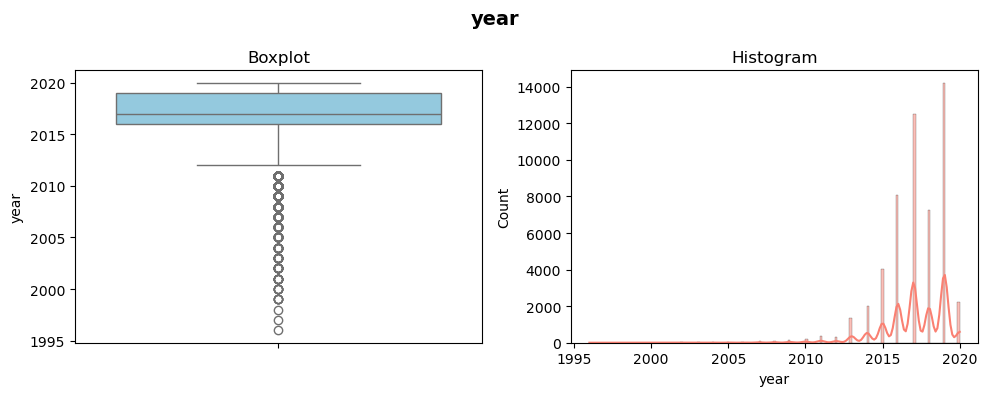

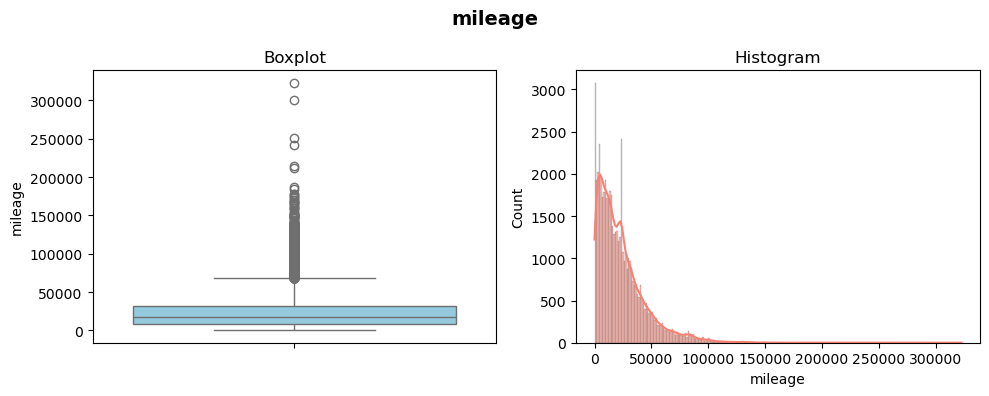

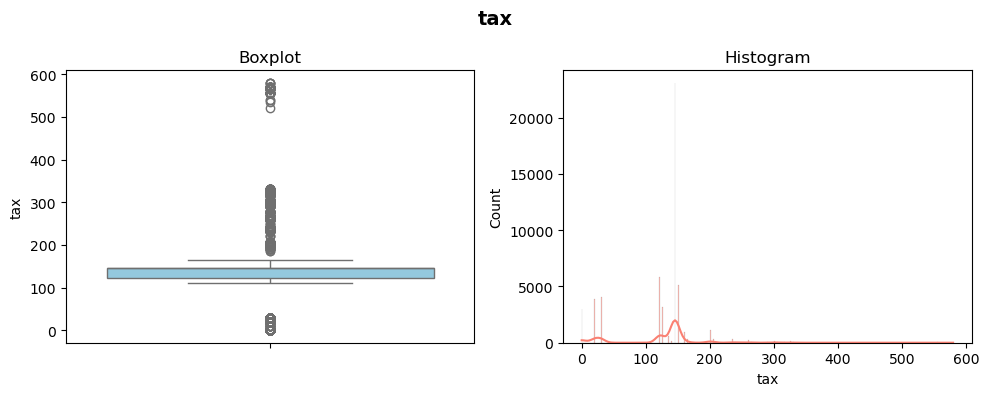

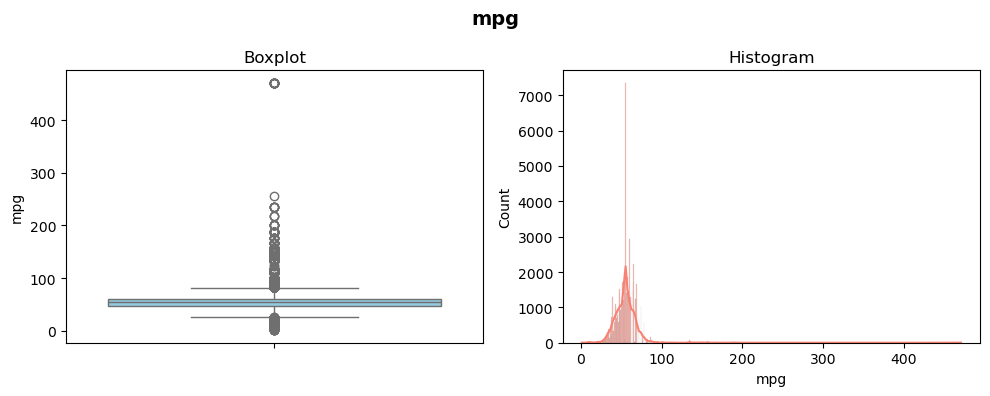

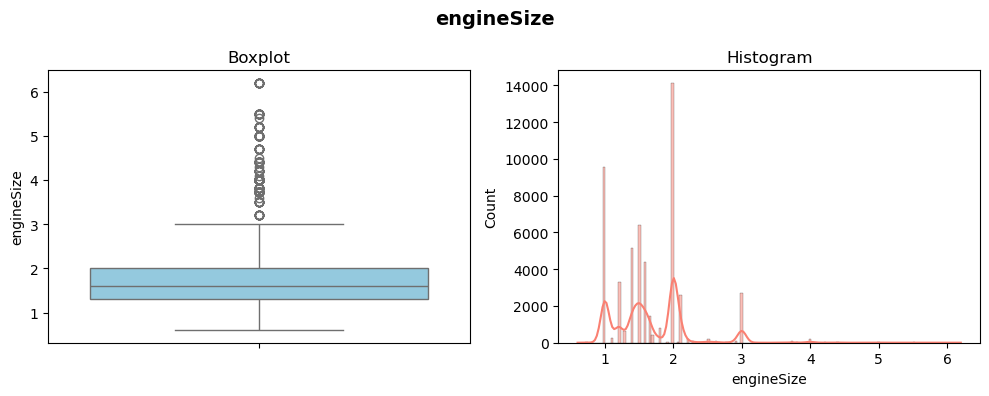

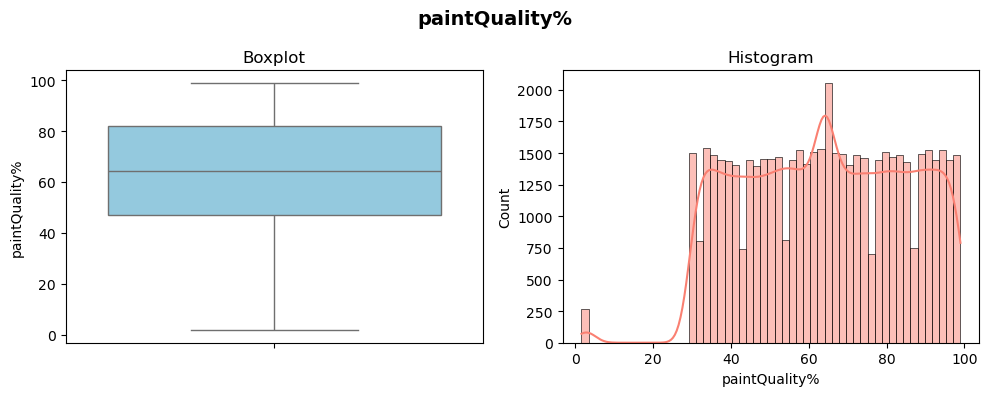

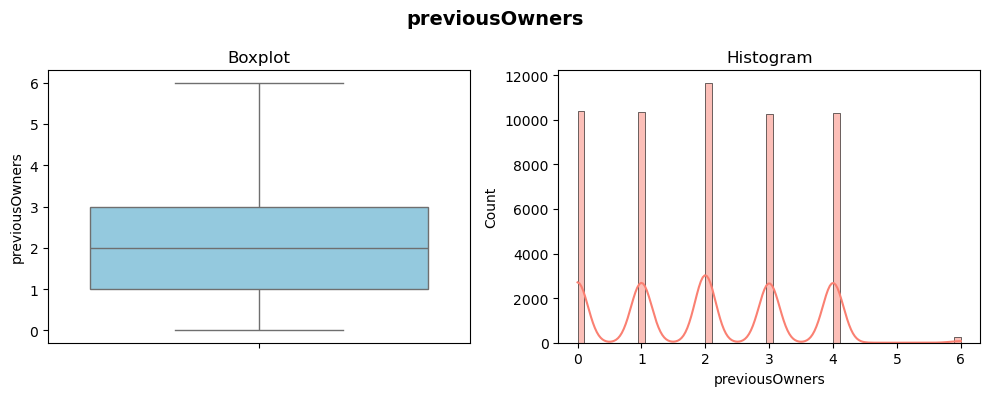

In [354]:
plot_nums(X_train, num_cols)

In [355]:
def outliers_skews(X):
    X=X.copy()

    #não mexer em colunas int (year, previouwsOwners)

    #log transform na mileage porque está skewed
    X["mileage"] = np.log1p(X["mileage"])

    #winsorization na tax e mpg e enginzeSize
    X["tax"] = X["tax"].clip(upper=X["tax"].quantile(0.975))
    X["mpg"] = X["mpg"].clip(upper=X["mpg"].quantile(0.975))
    X["engineSize"] = X["engineSize"].clip(lower=X["engineSize"].quantile(0.01), upper=X["engineSize"].quantile(0.99))

    return X

In [356]:
X_train = outliers_skews(X_train)
X_val = outliers_skews(X_val)

In [357]:
X_val

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,
7082,Audi,A4,2019,AUTOMATIC,8.580168,PETROL,145.000000,36.200000,2.0,83.0,1
40497,Mercedes,CCLASS,2016,SEMI-AUTO,10.173744,DIESEL,121.445982,55.181389,2.1,71.0,3
46065,Mercedes,ECLASS,2015,AUTOMATIC,10.655446,PETROL,235.000000,28.800000,3.0,43.0,3
17155,Ford,ECOSPORT,2018,MANUAL,9.864019,PETROL,145.000000,54.300000,1.0,60.0,4
34462,Hyundai,I800,2018,UNKNOWN,10.404202,DIESEL,145.000000,37.700000,2.5,62.0,1
...,...,...,...,...,...,...,...,...,...,...,...
50530,Skoda,FABIA,2017,SEMI-AUTO,9.881089,PETROL,145.000000,61.400000,1.0,40.0,2
41012,Mercedes,GLCLASS,2019,SEMI-AUTO,7.902857,DIESEL,145.000000,55.181389,2.0,87.0,2
68389,VW,UP,2017,MANUAL,10.412411,PETROL,20.000000,64.200000,1.0,86.0,2


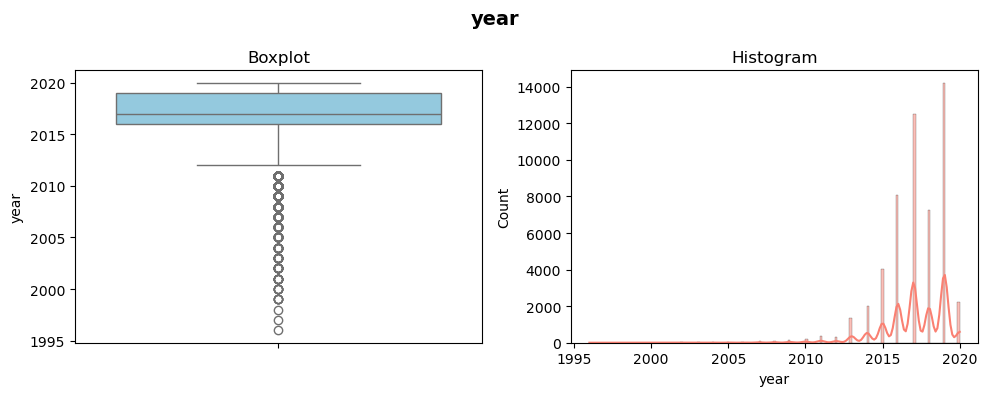

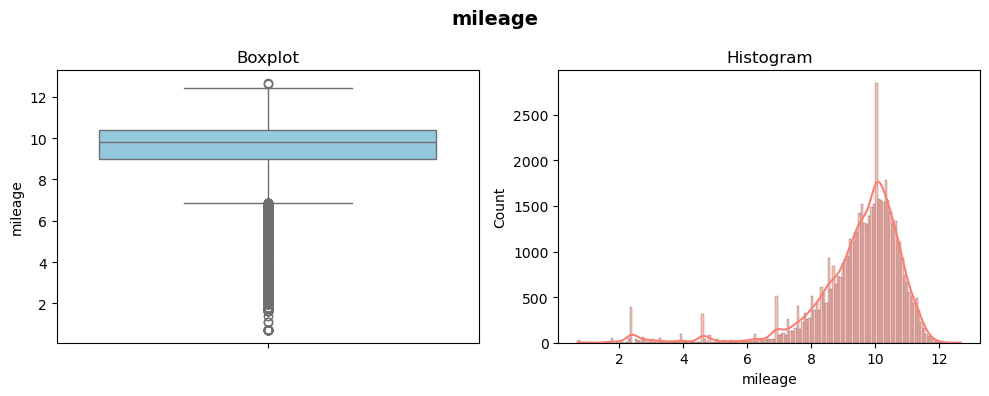

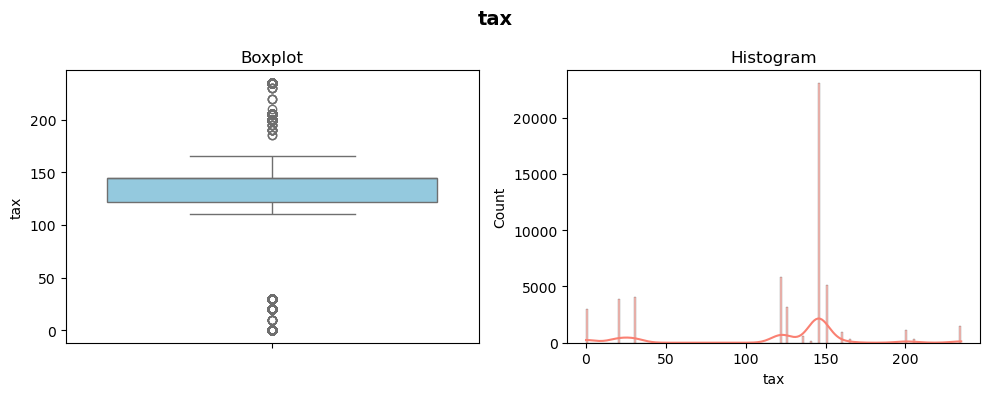

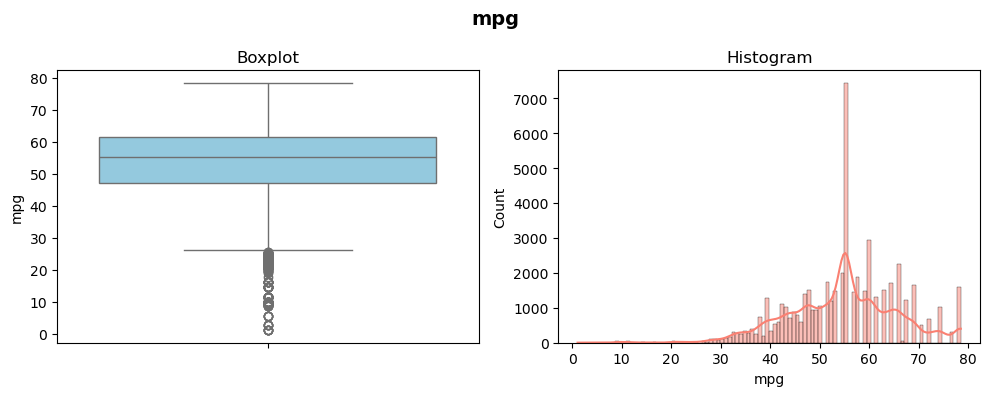

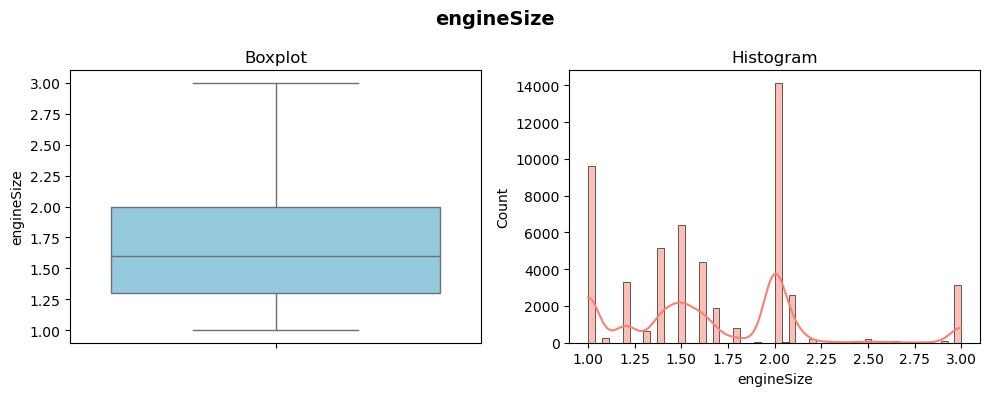

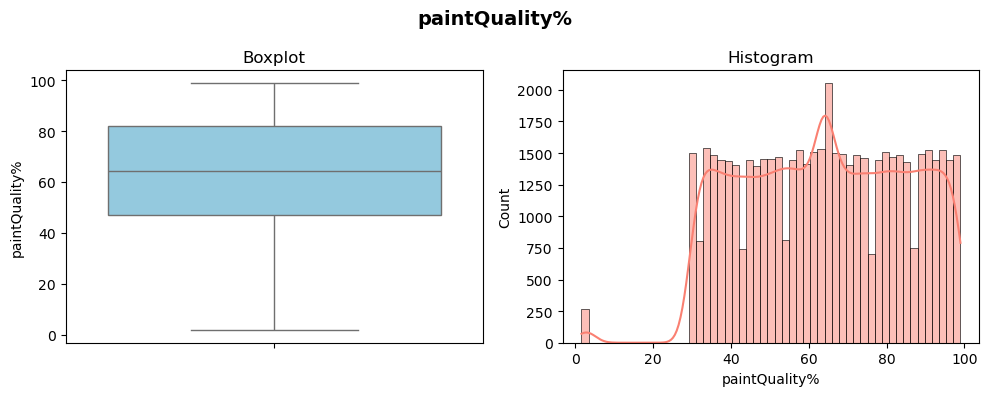

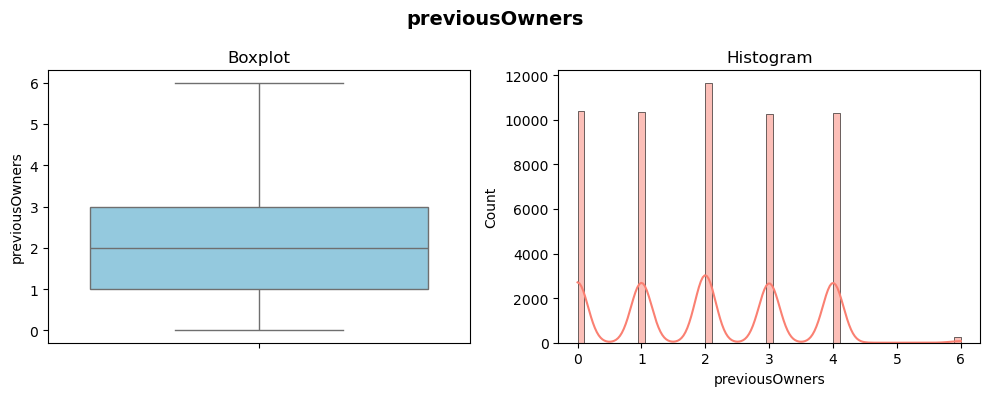

In [358]:
plot_nums(X_train, num_cols)

In [359]:
X_train_num = X_train[num_cols].copy()
X_train_cat = X_train[cat_cols].copy()

X_val_num = X_val[num_cols].copy()
X_val_cat = X_val[cat_cols].copy()

In [360]:
scaler = MinMaxScaler()
scaler.fit(X_train_num)
X_train_num_scaled = scaler.transform(X_train_num)
X_train_num_scaled

array([[0.95833333, 0.63204739, 0.61702128, ..., 0.15      , 0.45563467,
        0.33333333],
       [0.95833333, 0.66317479, 0.57446809, ..., 0.5       , 0.77403703,
        0.5       ],
       [1.        , 0.14215399, 0.61702128, ..., 0.        , 0.29129797,
        0.        ],
       ...,
       [0.79166667, 0.84176999, 0.08510638, ..., 0.        , 0.68159764,
        0.16666667],
       [0.875     , 0.81978055, 0.53191489, ..., 0.2       , 0.68159764,
        0.66666667],
       [0.79166667, 0.83355055, 0.53191489, ..., 0.55      , 0.53780302,
        0.        ]])

In [361]:
X_train_num_scaled = pd.DataFrame(X_train_num_scaled, columns = X_train_num.columns).set_index(X_train.index)
X_train_num_scaled

,year,mileage,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,
39423,0.958333,0.632047,0.617021,0.604651,0.15,0.455635,0.333333
9016,0.958333,0.663175,0.574468,1.000000,0.50,0.774037,0.500000
24121,1.000000,0.142154,0.617021,0.715762,0.00,0.291298,0.000000
57460,0.916667,0.774445,0.617021,0.492248,0.20,0.609700,0.000000
1936,1.000000,0.609856,0.617021,0.361757,0.95,0.917832,0.166667
...,...,...,...,...,...,...,...
33819,0.875000,0.765346,0.516791,0.649871,0.20,0.969187,0.666667
46982,0.958333,0.327042,0.617021,0.538760,0.50,0.702140,0.333333
71103,0.791667,0.841770,0.085106,0.797158,0.00,0.681598,0.166667


In [363]:
X_val_num_scaled = scaler.transform(X_val_num)
X_val_num_scaled = pd.DataFrame(X_val_num_scaled, columns = X_val_num.columns).set_index(X_val.index)
X_val_num_scaled

,year,mileage,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,
7082,0.958333,0.657676,0.617021,0.453488,0.50,0.835663,0.166667
40497,0.833333,0.790559,0.516791,0.698726,0.55,0.712411,0.500000
46065,0.791667,0.830727,1.000000,0.357881,1.00,0.424822,0.500000
17155,0.916667,0.764732,0.617021,0.687339,0.00,0.599429,0.666667
34462,0.916667,0.809777,0.617021,0.472868,0.75,0.619971,0.166667
...,...,...,...,...,...,...,...
50530,0.875000,0.766156,0.617021,0.779070,0.00,0.394008,0.333333
41012,0.958333,0.601197,0.617021,0.698726,0.50,0.876747,0.333333
68389,0.875000,0.810461,0.085106,0.815245,0.00,0.866476,0.333333


In [367]:
X_train_num_scaled.var()


year              0.007781
mileage           0.016104
tax               0.056344
mpg               0.020445
engineSize        0.065608
paintQuality%     0.043909
previousOwners    0.056276
dtype: float64

In [368]:
X_train_num.var()

year                4.481947
mileage             2.315915
tax               3111.57179
mpg               122.483658
engineSize          0.262432
paintQuality%     416.222702
previousOwners      2.025928
dtype: Float64

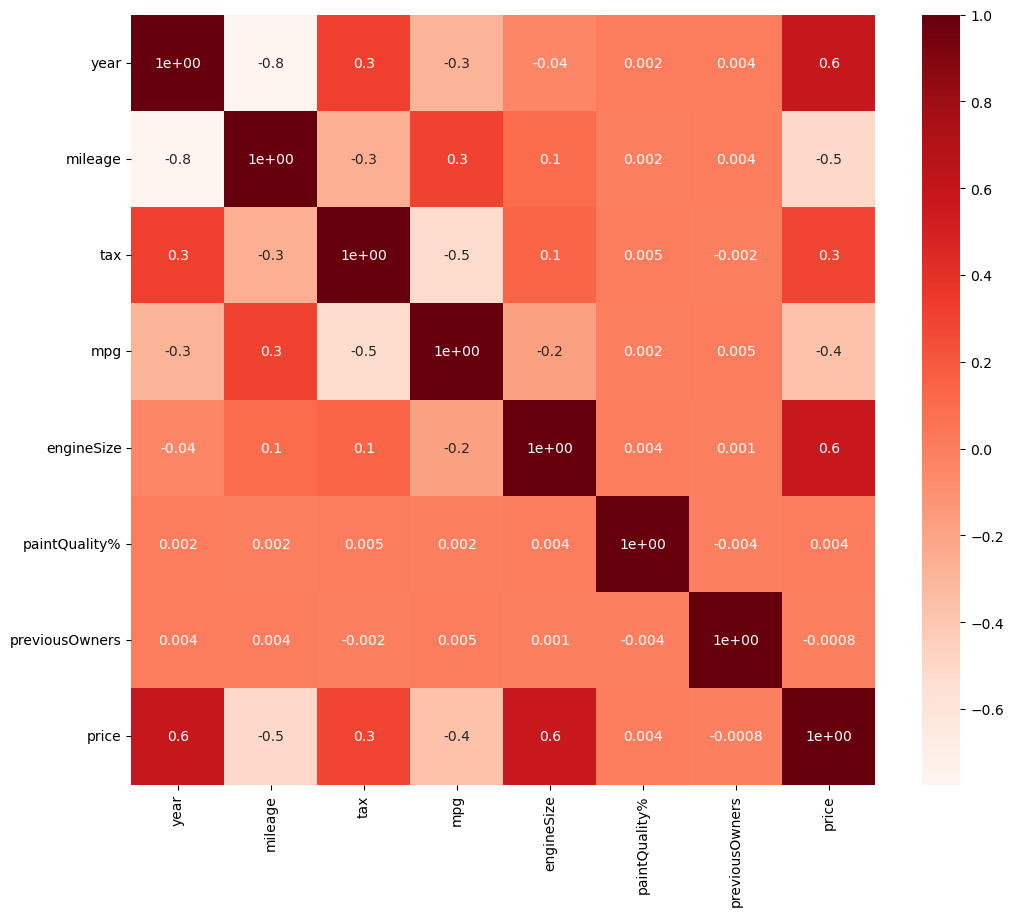

In [369]:
corr = X_train_num_scaled.assign(price=y_train).corr(method='spearman')
def cor_heatmap(cor):
    plt.figure(figsize=(12,10))
    sns.heatmap(data = cor, annot = True, cmap = plt.cm.Reds, fmt='.1')
    plt.show()
cor_heatmap(corr)

In [370]:
mi_scores = mutual_info_regression(X_train_num_scaled, y_train, random_state=0)
mi_scores = pd.Series(mi_scores, index=X_train_num_scaled.columns)
mi_scores.sort_values(ascending=False, inplace=True)
print(mi_scores)

engineSize        0.379613
mpg               0.364743
year              0.327638
mileage           0.304339
tax               0.190054
previousOwners    0.005993
paintQuality%     0.000000
dtype: float64


In [371]:
def TestIndependence(X,y,var,alpha=0.05):        
    dfObserved = pd.crosstab(y,X) 
    chi2, p, dof, expected = stats.chi2_contingency(dfObserved.values)
    dfExpected = pd.DataFrame(expected, columns=dfObserved.columns, index = dfObserved.index)
    if p<alpha:
        result="{0} is IMPORTANT for Prediction".format(var)
    else:
        result="{0} is NOT an important predictor. (Discard {0} from model)".format(var)
    print(result)

for var in X_train_cat:
    TestIndependence(X_train_cat[var],y_train, var)

Brand is IMPORTANT for Prediction
model is IMPORTANT for Prediction
transmission is IMPORTANT for Prediction
fuelType is NOT an important predictor. (Discard fuelType from model)


In [380]:
def cramers_v(x, y, var):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    result =  np.sqrt(chi2 / (n * (min(k - 1, r - 1))))
    print(f"{var}: {result}")

for var in X_train_cat:
    cramers_v(X_train_cat[var],y_train, var)

Brand: 0.4933647476641014
model: 0.4781827026647914
transmission: 0.4831311924601659
fuelType: 0.4022624471229654


In [382]:
def mutual_info(X, y, var):
    le = LabelEncoder()
    X_encoded = le.fit_transform(X.astype(str)).reshape(-1, 1)

    mi = mutual_info_classif(X_encoded, y, discrete_features=True, random_state=0)
    print(f"{var}: {mi[0]:.4f}")

for var in X_train_cat:
    mutual_info(X_train_cat[var],y_train, var)

Brand: 0.7444
model: 1.9133
transmission: 0.4324
fuelType: 0.2402


In [385]:
def anova(X_col, y, var):
    # Create list of target groups by category level
    groups = [y[X_col == level] for level in X_col.dropna().unique()]

    # Perform one-way ANOVA
    f_stat, p_val = f_oneway(*groups)

    print(f"{var.upper()}")
    print(f"  F-stat:  {f_stat:.3f}")
    print(f"  p-value: {p_val:.6f}")
    print("\n")  # line spacing between variables

    return pd.Series({"F-stat": f_stat, "p-value": p_val}, name=var)


for var in X_train_cat:
    anova(X_train_cat[var],y_train, var)

BRAND
  F-stat:  2381.016
  p-value: 0.000000


MODEL
  F-stat:  360.055
  p-value: 0.000000


TRANSMISSION
  F-stat:  5691.801
  p-value: 0.000000


FUELTYPE
  F-stat:  516.946
  p-value: 0.000000




**ANOVA** says: “These features cause significant average price differences.”

**MI** says: “These features explain uncertainty in price (model gives the most info).”

**Cramer’s V** says: “These variables have moderate categorical association strength."

In [390]:
model = LinearRegression()

In [392]:
rfe = RFE(estimator = model, n_features_to_select = 4)

In [394]:
X_rfe = rfe.fit_transform(X = X_train_num_scaled, y = y_train)

In [396]:
X_train_num_scaled.columns

Index(['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%',
       'previousOwners'],
      dtype='object')

In [398]:
rfe.support_

array([ True,  True, False,  True,  True, False, False])

In [400]:
rfe.ranking_

array([1, 1, 2, 1, 1, 3, 4])

In [402]:
selected_features = pd.Series(rfe.support_, index = X_train_num_scaled.columns)
selected_features

year               True
mileage            True
tax               False
mpg                True
engineSize         True
paintQuality%     False
previousOwners    False
dtype: bool

In [404]:
print(X_train_num_scaled.shape)
print(X_val_num_scaled.shape)
print(y_train.shape)
print(y_val.shape)


(53181, 7)
(22792, 7)
(53181,)
(22792,)


In [406]:
nof_list = np.arange(1, len(X_train_num_scaled.columns) + 1)
best_score = np.inf
best_n = 0

train_score_list = []
val_score_list = []

for n in nof_list:
    model = LinearRegression()
    rfe = RFE(estimator=model, n_features_to_select=n)
    
    # Fit RFE on training data
    X_train_rfe = rfe.fit_transform(X_train_num_scaled, y_train)
    X_val_rfe = rfe.transform(X_val_num_scaled)
    
    # Fit model
    model.fit(X_train_rfe, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train_rfe)
    y_val_pred = model.predict(X_val_rfe)
    
    # Compute RMSE manually
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    
    # Store negated RMSE (so higher = better for plotting)
    train_score_list.append(-train_rmse)
    val_score_list.append(-val_rmse)
    
    # Track best score (lowest RMSE)
    if val_rmse < best_score:
        best_score = val_rmse
        best_n = n

print(f"Optimum number of features: {best_n}")
print(f"Lowest validation RMSE ({best_n} features): {best_score:.4f}")


Optimum number of features: 5
Lowest validation RMSE (5 features): 5378.2162


In [665]:
plt.plot(nof_list, [-s for s in train_score_list], label='Train RMSE', color='lightgreen')
plt.plot(nof_list, [-s for s in val_score_list], label='Validation RMSE', color='gray')
plt.xlabel('Number of features')
plt.ylabel('RMSE')
plt.legend()
plt.show()

# Acho que há colinearidade entre variáveis como vimos antes, 4 sao suifciente

NameError: name 'nof_list' is not defined

SVR demora muito

In [412]:
#EFS é exaustivo, tenta TODAS as combinações de preditores, não usar cross validation aqui para não ter data leakage
#é permitido?
efs = EFS(
    estimator=model,
    min_features=1,
    max_features=len(X_train_num_scaled.columns),
    scoring=make_scorer(mean_squared_error, greater_is_better=False),
    n_jobs=-1            # parallelize
)

efs = efs.fit(X_train_num_scaled, y_train)  
rmse_train = np.sqrt(-efs.best_score_)

print("Best features:", efs.best_feature_names_)
print(f"Training RMSE: {rmse_train:.2f}")


Features: 127/127

Best features: ('year', 'mileage', 'tax', 'mpg', 'engineSize')
Training RMSE: 5608.01


In [413]:
selected = list(efs.best_feature_names_)

model.fit(X_train_num_scaled[selected], y_train)
y_val_pred = model.predict(X_val_num_scaled[selected])

rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
print(f"Validation RMSE: {rmse_val:.2f}")

Validation RMSE: 5378.22


In [414]:
reg = LassoCV()

In [418]:
reg.fit(X_train_num_scaled, y_train)

LassoCV()

In [420]:
coef = pd.Series(reg.coef_, index = X_train_num_scaled.columns)
coef.sort_values()

mileage          -14141.696977
mpg              -11896.597076
tax               -2172.830153
paintQuality%      -107.629734
previousOwners      -20.759555
engineSize        22294.266756
year              42233.546583
dtype: float64

In [422]:
# CODE HERE
print("Lasso picked " + str(sum(coef != 0)) + " variables and eliminated the other " +  str(sum(coef == 0)) + " variables")

Lasso picked 7 variables and eliminated the other 0 variables


In [424]:
def plot_importance(coef,name):
    imp_coef = coef.sort_values()
    plt.figure(figsize=(8,10))
    imp_coef.plot(kind = "barh")
    plt.title("Feature importance using " + name + " Model")
    plt.show()

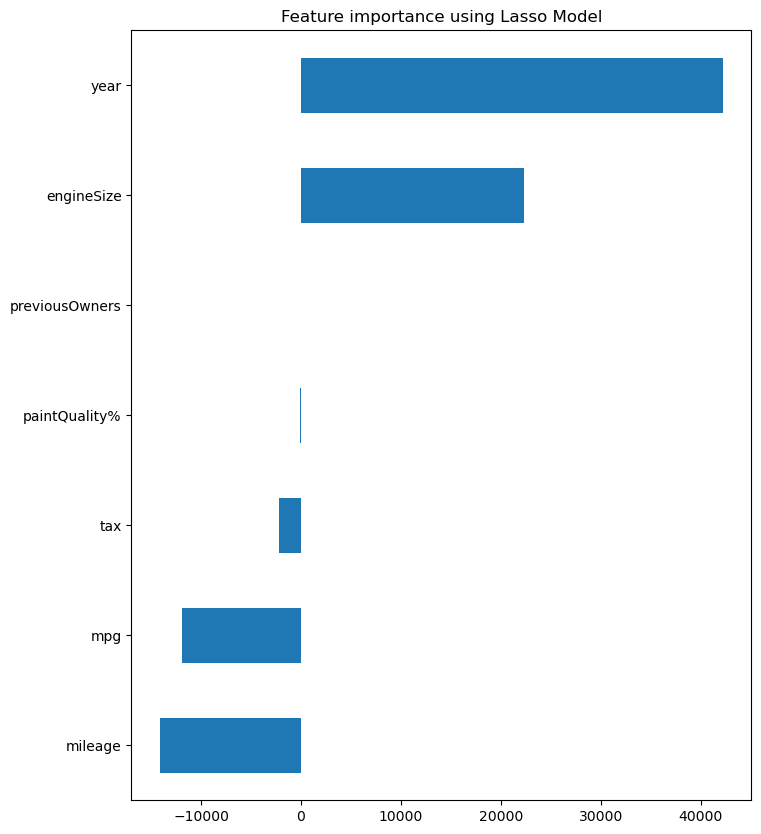

In [426]:
# CODE HERE
plot_importance(coef,'Lasso')

# Model Selection

In [429]:
def run_model(X, y, int_cols, float_cols,  model, scaler=None):
    X_processed = X.copy()
    
    #fill nas
    X_processed, fill_values = fill_nans(X_processed, int_cols, float_cols)

    #outliers
    X_processed = outliers_skews(X_processed)
        
    # Scale features
    if scaler is not None:
        X_processed = scaler.fit_transform(X_processed)
    
    # Fit the model
    model.fit(X_processed, y)
    
    return model, scaler, fill_values

In [431]:
def evaluate_model(X, y, model, int_cols, float_cols, fill_values, scaler=None, return_predictions=False):
    X_processed = X.copy()

    #fill with previously calculated values (noeakage)
    X_processed = fill_nans(X_processed, int_cols, float_cols, fill_values)

    #outliers
    X_processed = outliers_skews(X_processed) 
    
    # Apply same scaling as training
    if scaler is not None:
        X_processed = scaler.transform(X_processed)

    if return_predictions:
        return model.predict(X_processed)
    else:
        return model.score(X_processed, y)

In [433]:

def avg_score(method, X, y, int_cols, float_cols, model, scaler=None):
    mae_train, mae_val = [], []
    r2_train, r2_val = [], []

    for train_index, val_index in method.split(X, y):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        trained_model, fitted_scaler, fill_values = run_model(
            X_train, y_train, int_cols, float_cols, model, scaler
        )

        y_train_pred = evaluate_model(
            X_train, y_train, trained_model, int_cols, float_cols, fill_values, fitted_scaler, return_predictions=True
        )

        y_val_pred = evaluate_model(
            X_val, y_val, trained_model, int_cols, float_cols, fill_values, fitted_scaler, return_predictions=True
        )

        mae_train.append(mean_absolute_error(y_train, y_train_pred))
        mae_val.append(mean_absolute_error(y_val, y_val_pred))

        r2_train.append(r2_score(y_train, y_train_pred))
        r2_val.append(r2_score(y_val, y_val_pred))
    
    final_model, fitted_scaler, fill_values = run_model(
        X, y, int_cols, float_cols, model, scaler
    )

    print(f"Average Train MAE: {np.mean(mae_train):.4f}")
    print(f"Average Val MAE:   {np.mean(mae_val):.4f}")
    print(f"Average Train R²:  {np.mean(r2_train):.4f}")
    print(f"Average Val R²:    {np.mean(r2_val):.4f}")

    return {
        "mae_train": mae_train,
        "mae_val": mae_val,
        "r2_train": r2_train,
        "r2_val": r2_val,
        "final_model": final_model,
        "fitted_scaler": fitted_scaler,
        "fill_values": fill_values
    }

In [435]:
def predict_test(X_test, model, int_cols, float_cols, fill_values, scaler=None):
    X_processed = X_test.copy()

    # Fill missing values with training statistics (mean/median/etc.)
    X_processed = fill_nans(X_processed, int_cols, float_cols, fill_values)

    # Handle outliers/skew corrections using the same function
    X_processed = outliers_skews(X_processed)

    # Apply the same scaling as in training
    if scaler is not None:
        X_processed = scaler.transform(X_processed)

    # Return predictions
    return model.predict(X_processed)

# Model 1

## Attempt #1 : Linear Regression (All features, StandardScaler)

In [439]:
df=pd.read_csv("train.csv")
dfcopy = df.copy()
X=clean_df(dfcopy,valid_models)
X, y = separar_y(X)

In [441]:
display(X)

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,
69512,VW,GOLF,2016,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4
53000,Toyota,YARIS,2019,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,50.0,1
6366,Audi,Q2,2019,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,56.0,4
29021,Ford,FIESTA,2018,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,50.0,<NA>
10062,BMW,2SERIES,2019,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,97.0,3
...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,2015,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,78.0,0
6265,Audi,Q3,2013,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,38.0,2
54886,Toyota,AYGO,2017,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,57.0,3


In [443]:
X["previousOwners"].unique()

<IntegerArray>
[4, 1, <NA>, 3, 0, 2, 6]
Length: 7, dtype: Int64

In [445]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']
cat_cols = ['Brand', 'model', 'transmission', 'fuelType']
int_cols = ['year', 'previousOwners']
float_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%']   

In [447]:
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown="ignore")
encoded_array = ohe.fit_transform(X[cat_cols])
encoded_cols = ohe.get_feature_names_out(cat_cols)

In [449]:
X_encoded = pd.concat([
    X[num_cols].reset_index(drop=True),
    pd.DataFrame(encoded_array, columns=encoded_cols)
], axis=1)
X_encoded

,year,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,Brand_BMW,Brand_Ford,Brand_Hyundai,...,model_ZAFIRATOURER,transmission_MANUAL,transmission_OTHER,transmission_SEMI-AUTO,transmission_UNKNOWN,fuelType_ELECTRIC,fuelType_HYBRID,fuelType_OTHER,fuelType_PETROL,fuelType_UNKNOWN
0,2016,28421.0,NaN,11.417268,2.0,63.0,4,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2019,4589.0,145.0,47.900000,1.5,50.0,1,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2019,3624.0,145.0,40.900000,1.5,56.0,4,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2018,9102.0,145.0,65.700000,1.0,50.0,<NA>,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2019,1000.0,145.0,42.800000,1.5,97.0,3,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75968,2015,14480.0,125.0,53.300000,2.0,78.0,0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
75969,2013,52134.0,200.0,47.900000,2.0,38.0,2,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
75970,2017,11304.0,145.0,67.000000,1.0,57.0,3,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
75971,2015,69072.0,125.0,60.100000,2.0,74.0,2,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [451]:
grouped_cols = (
    pd.Series(X_encoded.columns)
    .groupby(X_encoded.columns.str.split("_").str[0])
    .apply(list)
)
grouped_cols

Brand             [Brand_BMW, Brand_Ford, Brand_Hyundai, Brand_M...
engineSize                                             [engineSize]
fuelType          [fuelType_ELECTRIC, fuelType_HYBRID, fuelType_...
mileage                                                   [mileage]
model             [model_2SERIES, model_3SERIES, model_4SERIES, ...
mpg                                                           [mpg]
paintQuality%                                       [paintQuality%]
previousOwners                                     [previousOwners]
tax                                                           [tax]
transmission      [transmission_MANUAL, transmission_OTHER, tran...
year                                                         [year]
dtype: object

In [453]:
model = LinearRegression()

In [455]:
scaler = StandardScaler()

In [457]:
kf = KFold(n_splits=7, shuffle=True, random_state=RANDOM_SEED)

In [459]:
results = avg_score(method=kf, X=X_encoded, y=y,int_cols=int_cols, float_cols=float_cols, model=model, scaler=scaler)

Average Train MAE: 2495.7475
Average Val MAE:   180763867536.0787
Average Train R²:  0.8294
Average Val R²:    -7526063685859387392.0000


In [461]:
results

{'mae_train': [2489.7158663372543,
  2499.5814111393993,
  2497.0502157801366,
  2508.105041628846,
  2497.1793312301147,
  2486.8975059805407,
  2491.7029453112414],
 'mae_val': [62683811355.123795,
  546638936549.30286,
  47527074900.34448,
  492642394674.1492,
  61620635510.59286,
  42733035719.368706,
  11501184043.669176],
 'r2_train': [0.8300736456813862,
  0.8271103978167126,
  0.8283981663724229,
  0.8269895571839474,
  0.829703592655006,
  0.8333295207209319,
  0.8299536394603153],
 'r2_val': [-4.592485677599375e+17,
  -3.4319305725763215e+19,
  -2.54897269617857e+17,
  -1.699615918261381e+19,
  -4.331796511201453e+17,
  -2.0451815078348576e+17,
  -1.5137253357267188e+16],
 'final_model': LinearRegression(),
 'fitted_scaler': StandardScaler(),
 'fill_values': {'float': {'mileage': 23352.797091695324,
   'tax': 121.25927623394078,
   'mpg': 55.204844209618095,
   'engineSize': 1.6710558716569128,
   'paintQuality%': 64.29011786822173},
  'int': {'year': 2017.0, 'previousOwners'

In [463]:
model = results["final_model"]
scaler = results["fitted_scaler"] 
fill_values = results["fill_values"]
#this is used right below for testing

Test:

In [468]:
test_df = pd.read_csv("test.csv")
test_copy = test_df.copy()
X_test = clean_df(test_copy, valid_models)
XcarID=X_test.copy()

In [470]:
display(XcarID)

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,
89856,Hyundai,I30,<NA>,AUTOMATIC,30700.0,PETROL,205.0,41.5,1.6,61.0,3
106581,VW,TIGUAN,2017,SEMI-AUTO,NaN,PETROL,150.0,38.2,2.0,60.0,2
80886,BMW,2SERIES,2016,AUTOMATIC,36792.0,PETROL,125.0,51.4,1.5,94.0,2
100174,Opel,GRANDLANDX,2019,MANUAL,5533.0,PETROL,145.0,44.1,1.2,77.0,1
81376,BMW,1SERIES,2019,SEMI-AUTO,9058.0,DIESEL,150.0,51.4,2.0,45.0,4
...,...,...,...,...,...,...,...,...,...,...,...
105775,VW,TIGUAN,2017,MANUAL,27575.0,PETROL,145.0,46.3,1.4,94.0,1
81363,BMW,X2,2020,AUTOMATIC,1980.0,PETROL,145.0,34.0,2.0,39.0,3
76833,Audi,Q5,2019,SEMI-AUTO,8297.0,DIESEL,145.0,38.2,2.0,88.0,4


In [472]:
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoded_test_array = ohe.fit_transform(X_test[cat_cols])
encoded_test_cols = ohe.get_feature_names_out(cat_cols)

In [474]:
X_test_encoded = pd.concat([
    X_test[num_cols].reset_index(drop=True),
    pd.DataFrame(encoded_test_array, columns=encoded_test_cols)
], axis=1)

In [476]:
X_test_encoded = X_test_encoded.reindex(columns=X_encoded.columns, fill_value=0)

In [478]:
len(X_test_encoded)

32567

In [480]:
y_pred = predict_test(
    X_test_encoded,
    model,
    int_cols,
    float_cols,
    fill_values,
    scaler
)

In [482]:
len(y_pred)

32567

In [484]:
len(test_df.index)

32567

In [839]:
submission = pd.DataFrame({
    "carID": XcarID.index,  
    "price": y_pred
})

# Check structure
display(submission.head())

# --- Save to CSV (with header, no index) ---
submission.to_csv("kaggle/model1.csv", index=False)

NameError: name 'XcarID' is not defined

In [490]:
submission

,carID,price
0,89856,14614.818471
1,106581,23934.193240
2,80886,13642.582678
3,100174,18490.017457
4,81376,22047.911406
...,...,...
32562,105775,17123.249236
32563,81363,31693.361996
32564,76833,32812.879298
32565,91768,22423.886605


In [492]:
aligned = (submission["carID"].values == XcarID.index.values)
aligned.all()

True

In [841]:
#to kaggle/model1.csv

# Model 2

## Attempt #2 : Linear Regression (Selected Features 1)

In [499]:
df=pd.read_csv("train.csv")
dfcopy = df.copy()
X=clean_df(dfcopy,valid_models)
X, y = separar_y(X)

In [501]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
cat_cols = ['Brand', 'model', 'transmission']
int_cols = ['year']
float_cols = ['mileage', 'tax', 'mpg', 'engineSize']

drop_cols = ['paintQuality%', 'previousOwners', 'fuelType']
X = X.drop(columns=drop_cols)

In [503]:
display(X)

,Brand,model,year,transmission,mileage,tax,mpg,engineSize
carID,,,,,,,,
69512,VW,GOLF,2016,SEMI-AUTO,28421.0,NaN,11.417268,2.0
53000,Toyota,YARIS,2019,MANUAL,4589.0,145.0,47.900000,1.5
6366,Audi,Q2,2019,SEMI-AUTO,3624.0,145.0,40.900000,1.5
29021,Ford,FIESTA,2018,MANUAL,9102.0,145.0,65.700000,1.0
10062,BMW,2SERIES,2019,MANUAL,1000.0,145.0,42.800000,1.5
...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,2015,MANUAL,14480.0,125.0,53.300000,2.0
6265,Audi,Q3,2013,SEMI-AUTO,52134.0,200.0,47.900000,2.0
54886,Toyota,AYGO,2017,AUTOMATIC,11304.0,145.0,67.000000,1.0


In [505]:
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown="ignore")
encoded_array = ohe.fit_transform(X[cat_cols])
encoded_cols = ohe.get_feature_names_out(cat_cols)

In [507]:
X_encoded = pd.concat([
    X[num_cols].reset_index(drop=True),
    pd.DataFrame(encoded_array, columns=encoded_cols)
], axis=1)
X_encoded

,year,mileage,tax,mpg,engineSize,Brand_BMW,Brand_Ford,Brand_Hyundai,Brand_Mercedes,Brand_Opel,...,model_YETIOUTDOO,model_YETIOUTDOOR,model_Z3,model_Z4,model_ZAFIRA,model_ZAFIRATOURER,transmission_MANUAL,transmission_OTHER,transmission_SEMI-AUTO,transmission_UNKNOWN
0,2016,28421.0,NaN,11.417268,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2019,4589.0,145.0,47.900000,1.5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2019,3624.0,145.0,40.900000,1.5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2018,9102.0,145.0,65.700000,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,2019,1000.0,145.0,42.800000,1.5,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75968,2015,14480.0,125.0,53.300000,2.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
75969,2013,52134.0,200.0,47.900000,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
75970,2017,11304.0,145.0,67.000000,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75971,2015,69072.0,125.0,60.100000,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [509]:
model = LinearRegression()
scaler = StandardScaler()
kf = KFold(n_splits=7, shuffle=True, random_state=RANDOM_SEED)
results = avg_score(method=kf, X=X_encoded, y=y,int_cols=int_cols, float_cols=float_cols, model=model, scaler=scaler)

Average Train MAE: 2526.1087
Average Val MAE:   1090769242860.1234
Average Train R²:  0.8260
Average Val R²:    -145148618645696135168.0000


In [511]:
results

{'mae_train': [2518.605933386487,
  2529.0514246392736,
  2527.5253930836193,
  2542.9068505988926,
  2526.840806316941,
  2516.5720585502395,
  2521.258300642238],
 'mae_val': [214434379842.18927,
  3013065292697.293,
  421507528501.26825,
  1777001960001.0195,
  2160837823599.6375,
  2569.8963377873188,
  48537712809.56041],
 'r2_train': [0.8267800178462296,
  0.8237679472281766,
  0.8249593224282388,
  0.8232092718451546,
  0.8264075660394912,
  0.8299721503379932,
  0.8266389500670047],
 'r2_val': [-1.938838558950859e+18,
  -6.815014435805904e+20,
  -9.108371801887887e+18,
  -1.3616369510266628e+20,
  -1.8705833746660478e+20,
  0.800658593192637,
  -2.696440091728209e+17],
 'final_model': LinearRegression(),
 'fitted_scaler': StandardScaler(),
 'fill_values': {'float': {'mileage': 23352.797091695324,
   'tax': 121.25927623394078,
   'mpg': 55.204844209618095,
   'engineSize': 1.6710558716569128},
  'int': {'year': 2017.0}}}

In [513]:
model = results["final_model"]
scaler = results["fitted_scaler"] 
fill_values = results["fill_values"]
#this is used right below for testing

Test:

In [516]:
test_df = pd.read_csv("test.csv")
test_copy = test_df.copy()
X_test = clean_df(test_copy, valid_models)
X_test = X_test.drop(columns=drop_cols)
XcarID=X_test.copy()

In [518]:
display(XcarID)

,Brand,model,year,transmission,mileage,tax,mpg,engineSize
carID,,,,,,,,
89856,Hyundai,I30,<NA>,AUTOMATIC,30700.0,205.0,41.5,1.6
106581,VW,TIGUAN,2017,SEMI-AUTO,NaN,150.0,38.2,2.0
80886,BMW,2SERIES,2016,AUTOMATIC,36792.0,125.0,51.4,1.5
100174,Opel,GRANDLANDX,2019,MANUAL,5533.0,145.0,44.1,1.2
81376,BMW,1SERIES,2019,SEMI-AUTO,9058.0,150.0,51.4,2.0
...,...,...,...,...,...,...,...,...
105775,VW,TIGUAN,2017,MANUAL,27575.0,145.0,46.3,1.4
81363,BMW,X2,2020,AUTOMATIC,1980.0,145.0,34.0,2.0
76833,Audi,Q5,2019,SEMI-AUTO,8297.0,145.0,38.2,2.0


In [520]:
encoded_test_array = ohe.fit_transform(X_test[cat_cols])
encoded_test_cols = ohe.get_feature_names_out(cat_cols)

In [522]:
X_test_encoded = pd.concat([
    X_test[num_cols].reset_index(drop=True),
    pd.DataFrame(encoded_test_array, columns=encoded_test_cols)
], axis=1)

In [524]:
X_test_encoded = X_test_encoded.reindex(columns=X_encoded.columns, fill_value=0)

In [526]:
len(X_test_encoded)

32567

In [528]:
y_pred = predict_test(
    X_test_encoded,
    model,
    int_cols,
    float_cols,
    fill_values,
    scaler
)

In [530]:
len(y_pred)

32567

In [532]:
len(test_df.index)

32567

In [536]:
submission = pd.DataFrame({
    "carID": XcarID.index,  
    "price": y_pred
})

# Check structure
display(submission.head())

# --- Save to CSV (with header, no index) ---
submission.to_csv("kaggle/model2.csv", index=False)

,carID,price
0,89856,14603.730027
1,106581,23247.574965
2,80886,13634.655968
3,100174,18145.676545
4,81376,22643.098266


In [538]:
submission

,carID,price
0,89856,14603.730027
1,106581,23247.574965
2,80886,13634.655968
3,100174,18145.676545
4,81376,22643.098266
...,...,...
32562,105775,16457.121071
32563,81363,31384.414781
32564,76833,33307.111573
32565,91768,22309.819512


In [540]:
aligned = (submission["carID"].values == XcarID.index.values)
aligned.all()

True

In [843]:
#to kaggle/model2.csv

# Model 3

## Attempt #3 : Linear Regression (Selected Features 3)

In [547]:
df=pd.read_csv("train.csv")
dfcopy = df.copy()
X=clean_df(dfcopy,valid_models)
X, y = separar_y(X)

In [549]:
num_cols = ['year', 'mileage', 'mpg', 'engineSize']
cat_cols = ['Brand', 'model', 'transmission']
int_cols = ['year']
float_cols = ['mileage', 'mpg', 'engineSize']

drop_cols = ['paintQuality%', 'previousOwners', 'fuelType', 'tax']
X = X.drop(columns=drop_cols)

In [551]:
old_outliers_skews = outliers_skews
def outliers_skews(X):
    X=X.copy()

    #não mexer em colunas int (year, previouwsOwners)

    #log transform na mileage porque está skewed
    X["mileage"] = np.log1p(X["mileage"])

    #winsorization na tax e mpg e enginzeSize
    #X["tax"] = X["tax"].clip(upper=X["tax"].quantile(0.975))
    X["mpg"] = X["mpg"].clip(upper=X["mpg"].quantile(0.975))
    X["engineSize"] = X["engineSize"].clip(lower=X["engineSize"].quantile(0.01), upper=X["engineSize"].quantile(0.99))

    return X

In [553]:
display(X)

,Brand,model,year,transmission,mileage,mpg,engineSize
carID,,,,,,,
69512,VW,GOLF,2016,SEMI-AUTO,28421.0,11.417268,2.0
53000,Toyota,YARIS,2019,MANUAL,4589.0,47.900000,1.5
6366,Audi,Q2,2019,SEMI-AUTO,3624.0,40.900000,1.5
29021,Ford,FIESTA,2018,MANUAL,9102.0,65.700000,1.0
10062,BMW,2SERIES,2019,MANUAL,1000.0,42.800000,1.5
...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,2015,MANUAL,14480.0,53.300000,2.0
6265,Audi,Q3,2013,SEMI-AUTO,52134.0,47.900000,2.0
54886,Toyota,AYGO,2017,AUTOMATIC,11304.0,67.000000,1.0


In [555]:
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown="ignore")
encoded_array = ohe.fit_transform(X[cat_cols])
encoded_cols = ohe.get_feature_names_out(cat_cols)

In [557]:
X_encoded = pd.concat([
    X[num_cols].reset_index(drop=True),
    pd.DataFrame(encoded_array, columns=encoded_cols)
], axis=1)
X_encoded

,year,mileage,mpg,engineSize,Brand_BMW,Brand_Ford,Brand_Hyundai,Brand_Mercedes,Brand_Opel,Brand_Skoda,...,model_YETIOUTDOO,model_YETIOUTDOOR,model_Z3,model_Z4,model_ZAFIRA,model_ZAFIRATOURER,transmission_MANUAL,transmission_OTHER,transmission_SEMI-AUTO,transmission_UNKNOWN
0,2016,28421.0,11.417268,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2019,4589.0,47.900000,1.5,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2019,3624.0,40.900000,1.5,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2018,9102.0,65.700000,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,2019,1000.0,42.800000,1.5,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75968,2015,14480.0,53.300000,2.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
75969,2013,52134.0,47.900000,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
75970,2017,11304.0,67.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75971,2015,69072.0,60.100000,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [559]:
model = LinearRegression()
scaler = StandardScaler()
kf = KFold(n_splits=7, shuffle=True, random_state=RANDOM_SEED)
results = avg_score(method=kf, X=X_encoded, y=y,int_cols=int_cols, float_cols=float_cols, model=model, scaler=scaler)

Average Train MAE: 2536.8454
Average Val MAE:   778871074874.3252
Average Train R²:  0.8237
Average Val R²:    -76505293761696661504.0000


In [561]:
results

{'mae_train': [2530.1490921925956,
  2539.269395847431,
  2538.2106549596792,
  2551.1173940222816,
  2537.013483780061,
  2528.668754678929,
  2533.4891181584153],
 'mae_val': [1279146956145.2654,
  24244544294.629253,
  256154910756.21866,
  1550573342076.671,
  1885437243127.1428,
  2571.426099939626,
  456540525148.9241],
 'r2_train': [0.8245957332682768,
  0.8215350256838699,
  0.8227371635964773,
  0.8210128703128134,
  0.8242499499572244,
  0.8276548036071629,
  0.8243997413300662],
 'r2_val': [-7.515085828350668e+19,
  -6.75095684885215e+16,
  -7.404375254240439e+18,
  -8.881246612587492e+19,
  -3.40246218231841e+20,
  0.7988227447131103,
  -2.385562886792497e+19],
 'final_model': LinearRegression(),
 'fitted_scaler': StandardScaler(),
 'fill_values': {'float': {'mileage': 23352.797091695324,
   'mpg': 55.204844209618095,
   'engineSize': 1.6710558716569128},
  'int': {'year': 2017.0}}}

In [563]:
model = results["final_model"]
scaler = results["fitted_scaler"] 
fill_values = results["fill_values"]
#this is used right below for testing

Test:

In [566]:
test_df = pd.read_csv("test.csv")
test_copy = test_df.copy()
X_test = clean_df(test_copy, valid_models)
X_test = X_test.drop(columns=drop_cols)
XcarID=X_test.copy()

In [568]:
display(XcarID)

,Brand,model,year,transmission,mileage,mpg,engineSize
carID,,,,,,,
89856,Hyundai,I30,<NA>,AUTOMATIC,30700.0,41.5,1.6
106581,VW,TIGUAN,2017,SEMI-AUTO,NaN,38.2,2.0
80886,BMW,2SERIES,2016,AUTOMATIC,36792.0,51.4,1.5
100174,Opel,GRANDLANDX,2019,MANUAL,5533.0,44.1,1.2
81376,BMW,1SERIES,2019,SEMI-AUTO,9058.0,51.4,2.0
...,...,...,...,...,...,...,...
105775,VW,TIGUAN,2017,MANUAL,27575.0,46.3,1.4
81363,BMW,X2,2020,AUTOMATIC,1980.0,34.0,2.0
76833,Audi,Q5,2019,SEMI-AUTO,8297.0,38.2,2.0


In [570]:
encoded_test_array = ohe.fit_transform(X_test[cat_cols])
encoded_test_cols = ohe.get_feature_names_out(cat_cols)

In [572]:
X_test_encoded = pd.concat([
    X_test[num_cols].reset_index(drop=True),
    pd.DataFrame(encoded_test_array, columns=encoded_test_cols)
], axis=1)

In [574]:
X_test_encoded = X_test_encoded.reindex(columns=X_encoded.columns, fill_value=0)

In [576]:
len(X_test_encoded)

32567

In [578]:
y_pred = predict_test(
    X_test_encoded,
    model,
    int_cols,
    float_cols,
    fill_values,
    scaler
)

In [580]:
len(y_pred)

32567

In [582]:
len(test_df.index)

32567

In [586]:
submission = pd.DataFrame({
    "carID": XcarID.index,  
    "price": y_pred
})

# Check structure
display(submission.head())

# --- Save to CSV (with header, no index) ---
submission.to_csv("kaggle/model3.csv", index=False)

,carID,price
0,89856,15098.637710
1,106581,23019.355695
2,80886,13627.287847
3,100174,17949.512105
4,81376,22789.567474


In [588]:
submission

,carID,price
0,89856,15098.637710
1,106581,23019.355695
2,80886,13627.287847
3,100174,17949.512105
4,81376,22789.567474
...,...,...
32562,105775,16476.767884
32563,81363,30999.957931
32564,76833,32895.708164
32565,91768,21921.028492


In [590]:
aligned = (submission["carID"].values == XcarID.index.values)
aligned.all()
outliers_skews = old_outliers_skews


In [592]:
#to kaggle/model3.csv

# Model 4

## Attempt #4 : Random Forest (All Features, OHE Encoding)

In [597]:
df=pd.read_csv("train.csv")
dfcopy = df.copy()
X=clean_df(dfcopy,valid_models)
X, y = separar_y(X)

In [599]:
display(X)

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,
69512,VW,GOLF,2016,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4
53000,Toyota,YARIS,2019,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,50.0,1
6366,Audi,Q2,2019,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,56.0,4
29021,Ford,FIESTA,2018,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,50.0,<NA>
10062,BMW,2SERIES,2019,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,97.0,3
...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,2015,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,78.0,0
6265,Audi,Q3,2013,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,38.0,2
54886,Toyota,AYGO,2017,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,57.0,3


In [601]:
X["previousOwners"].unique()

<IntegerArray>
[4, 1, <NA>, 3, 0, 2, 6]
Length: 7, dtype: Int64

In [603]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']
cat_cols = ['Brand', 'model', 'transmission', 'fuelType']
int_cols = ['year', 'previousOwners']
float_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%']   

In [605]:
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown="ignore")
encoded_array = ohe.fit_transform(X[cat_cols])
encoded_cols = ohe.get_feature_names_out(cat_cols)

In [607]:
X_encoded = pd.concat([
    X[num_cols].reset_index(drop=True),
    pd.DataFrame(encoded_array, columns=encoded_cols)
], axis=1)
X_encoded

,year,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,Brand_BMW,Brand_Ford,Brand_Hyundai,...,model_ZAFIRATOURER,transmission_MANUAL,transmission_OTHER,transmission_SEMI-AUTO,transmission_UNKNOWN,fuelType_ELECTRIC,fuelType_HYBRID,fuelType_OTHER,fuelType_PETROL,fuelType_nan
0,2016,28421.0,NaN,11.417268,2.0,63.0,4,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2019,4589.0,145.0,47.900000,1.5,50.0,1,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2019,3624.0,145.0,40.900000,1.5,56.0,4,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2018,9102.0,145.0,65.700000,1.0,50.0,<NA>,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2019,1000.0,145.0,42.800000,1.5,97.0,3,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75968,2015,14480.0,125.0,53.300000,2.0,78.0,0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
75969,2013,52134.0,200.0,47.900000,2.0,38.0,2,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
75970,2017,11304.0,145.0,67.000000,1.0,57.0,3,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
75971,2015,69072.0,125.0,60.100000,2.0,74.0,2,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [609]:
grouped_cols = (
    pd.Series(X_encoded.columns)
    .groupby(X_encoded.columns.str.split("_").str[0])
    .apply(list)
)
grouped_cols

Brand             [Brand_BMW, Brand_Ford, Brand_Hyundai, Brand_M...
engineSize                                             [engineSize]
fuelType          [fuelType_ELECTRIC, fuelType_HYBRID, fuelType_...
mileage                                                   [mileage]
model             [model_2SERIES, model_3SERIES, model_4SERIES, ...
mpg                                                           [mpg]
paintQuality%                                       [paintQuality%]
previousOwners                                     [previousOwners]
tax                                                           [tax]
transmission      [transmission_MANUAL, transmission_OTHER, tran...
year                                                         [year]
dtype: object

In [611]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=RANDOM_SEED
)

In [613]:

param_dist = {
    "n_estimators": [50, 75, 100, 150, 200, 300, 400, 500, 600],
    "max_depth": [5, 7, 10, 15, 20, 25, 30],
    "min_samples_split": [2, 4, 5, 10, 12, 15],
    "min_samples_leaf": [1, 2, 5, 7, 10],
    "max_features": ["sqrt", "log2", 0.8, 0.5, 0.7],
    "max_samples": [0.7, 0.8, 0.9],
    "bootstrap": [True]
}

n_iter = 60
param_samples = [
    {key: random.choice(values) for key, values in param_dist.items()}
    for _ in range(n_iter)
]

kf_search = KFold(n_splits=7, shuffle=True, random_state=RANDOM_SEED)
cv_search_results = []

print("Randomized Search with 7-Fold Cross-Validation (MAE Optimization)\n")
print(f"Testing {n_iter} random parameter combinations\n")


for i, params in enumerate(param_samples, start=1):
    fold_mae_scores = []
    fold_r2_scores = []

    print(f"► Combination {i}/{n_iter}: {params}")

    for fold, (train_idx, val_idx) in enumerate(kf_search.split(X_train_val, y_train_val), start=1):
        X_fold_train = X_train_val.iloc[train_idx]
        y_fold_train = y_train_val.iloc[train_idx]
        X_fold_val = X_train_val.iloc[val_idx]
        y_fold_val = y_train_val.iloc[val_idx]

        # --- Model ---
        model = RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1, **params)

        # --- Train ---
        trained_model, fitted_scaler, fill_values = run_model(
            X_fold_train, y_fold_train,
            int_cols=int_cols,
            float_cols=float_cols,
            model=model,
            scaler=None
        )

        # --- Predict & Evaluate manually ---
        y_val_pred = evaluate_model(
            X_fold_val, y_fold_val,
            trained_model,
            int_cols=int_cols,
            float_cols=float_cols,
            fill_values=fill_values,
            scaler=fitted_scaler,
            return_predictions=True
        )

        # Compute metrics
        mae = mean_absolute_error(y_fold_val, y_val_pred)
        r2 = r2_score(y_fold_val, y_val_pred)

        fold_mae_scores.append(mae)
        fold_r2_scores.append(r2)

        print(f"   Fold {fold}: MAE = {mae:.4f}, R² = {r2:.4f}")

    # --- Average metrics ---
    mean_mae = np.mean(fold_mae_scores)
    std_mae = np.std(fold_mae_scores)
    mean_r2 = np.mean(fold_r2_scores)
    std_r2 = np.std(fold_r2_scores)

    cv_search_results.append({
        **params,
        "mean_mae": mean_mae,
        "std_mae": std_mae,
        "mean_r2": mean_r2,
        "std_r2": std_r2
    })

    print(f"→ Mean CV MAE: {mean_mae:.4f} | Mean R²: {mean_r2:.4f}\n")

# --- Best parameters based on MAE (lower is better) ---
best_result = min(cv_search_results, key=lambda x: x["mean_mae"])

best_params = {
    k: v for k, v in best_result.items()
    if k not in ["mean_mae", "std_mae", "mean_r2", "std_r2"]
}

print("Best Parameters (based on lowest MAE):")
for k, v in best_result.items():
    if k not in ["mean_mae", "std_mae", "mean_r2", "std_r2"]:
        print(f"  {k}: {v}")

print(f"\nBest CV MAE: {best_result['mean_mae']:.4f} (+/- {best_result['std_mae']:.4f})")
print(f"Best CV R²:  {best_result['mean_r2']:.4f} (+/- {best_result['std_r2']:.4f})")


Randomized Search with 7-Fold Cross-Validation (MAE Optimization)

Testing 60 random parameter combinations

► Combination 1/60: {'n_estimators': 150, 'max_depth': 7, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_features': 0.7, 'max_samples': 0.9, 'bootstrap': True}
   Fold 1: MAE = 2492.7314, R² = 0.8416
   Fold 2: MAE = 2434.9945, R² = 0.8518
   Fold 3: MAE = 2485.1266, R² = 0.8308
   Fold 4: MAE = 2433.1857, R² = 0.8502
   Fold 5: MAE = 2531.3842, R² = 0.8372
   Fold 6: MAE = 2478.5592, R² = 0.8481
   Fold 7: MAE = 2478.3725, R² = 0.8240
→ Mean CV MAE: 2476.3363 | Mean R²: 0.8405

► Combination 2/60: {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.8, 'max_samples': 0.7, 'bootstrap': True}
   Fold 1: MAE = 2015.0568, R² = 0.8925
   Fold 2: MAE = 1989.7410, R² = 0.8963
   Fold 3: MAE = 2007.4150, R² = 0.8801
   Fold 4: MAE = 1967.6289, R² = 0.8992
   Fold 5: MAE = 2035.2771, R² = 0.8942
   Fold 6: MAE = 2011.5898, R² = 0.

In [663]:
best_params

{'n_estimators': 150,
 'max_depth': 30,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 0.7,
 'max_samples': 0.8,
 'bootstrap': True}

In [665]:
rf_model = RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1, **best_params)
kf=KFold(n_splits=7, shuffle=True, random_state=RANDOM_SEED)

In [667]:
results = avg_score(kf, X_encoded, y, int_cols, float_cols, rf_model, scaler=None)
#isto tem overfitting NITIDO

Average Train MAE: 668.0654
Average Val MAE:   1387.8272
Average Train R²:  0.9862
Average Val R²:    0.9379


In [671]:
model = results["final_model"]
fill_values = results["fill_values"]

Test:

In [674]:
test_df = pd.read_csv("test.csv")
test_copy = test_df.copy()
X_test = clean_df(test_copy, valid_models)
XcarID=X_test.copy()

In [676]:
display(XcarID)

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,
89856,Hyundai,I30,<NA>,AUTOMATIC,30700.0,PETROL,205.0,41.5,1.6,61.0,3
106581,VW,TIGUAN,2017,SEMI-AUTO,NaN,PETROL,150.0,38.2,2.0,60.0,2
80886,BMW,2SERIES,2016,AUTOMATIC,36792.0,PETROL,125.0,51.4,1.5,94.0,2
100174,Opel,GRANDLANDX,2019,MANUAL,5533.0,PETROL,145.0,44.1,1.2,77.0,1
81376,BMW,1SERIES,2019,SEMI-AUTO,9058.0,DIESEL,150.0,51.4,2.0,45.0,4
...,...,...,...,...,...,...,...,...,...,...,...
105775,VW,TIGUAN,2017,MANUAL,27575.0,PETROL,145.0,46.3,1.4,94.0,1
81363,BMW,X2,2020,AUTOMATIC,1980.0,PETROL,145.0,34.0,2.0,39.0,3
76833,Audi,Q5,2019,SEMI-AUTO,8297.0,DIESEL,145.0,38.2,2.0,88.0,4


In [678]:
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoded_test_array = ohe.fit_transform(X_test[cat_cols])
encoded_test_cols = ohe.get_feature_names_out(cat_cols)

In [680]:
X_test_encoded = pd.concat([
    X_test[num_cols].reset_index(drop=True),
    pd.DataFrame(encoded_test_array, columns=encoded_test_cols)
], axis=1)

In [682]:
X_test_encoded = X_test_encoded.reindex(columns=X_encoded.columns, fill_value=0)

In [684]:
len(X_test_encoded)

32567

In [686]:
y_pred = predict_test(
    X_test_encoded,
    model,
    int_cols,
    float_cols,
    fill_values
)

In [688]:
len(y_pred)

32567

In [690]:
len(test_df.index)

32567

In [692]:
submission = pd.DataFrame({
    "carID": XcarID.index,  
    "price": y_pred
})

# Check structure
display(submission.head())

# --- Save to CSV (with header, no index) ---
submission.to_csv("kaggle/model7.csv", index=False)

,carID,price
0,89856,12404.329723
1,106581,23993.150601
2,80886,13824.550962
3,100174,16803.237393
4,81376,25791.784428


OSError: Cannot save file into a non-existent directory: 'kaggle'

In [694]:
submission

,carID,price
0,89856,12404.329723
1,106581,23993.150601
2,80886,13824.550962
3,100174,16803.237393
4,81376,25791.784428
...,...,...
32562,105775,17465.806243
32563,81363,35932.416051
32564,76833,33203.026667
32565,91768,20768.455000


In [696]:
aligned = (submission["carID"].values == XcarID.index.values)
aligned.all()

True

In [240]:
#to kaggle/model4.csv

# Model 5

## Attempt #5: Random Forest (All Features, Frequency Encoding)

In [241]:
"""Frequency encoding logic"""
def frequency_encode_train(df, cat_cols):
    df_encoded = df.copy()
    
    freq_values = {}
    for col in cat_cols:
        freq_map = df[col].value_counts(normalize=True)

        #this needed in order to not have data leakage when applying to test data, there will be classes that are not in the training dataset
        #due to the fact that the strings were corrupted and pre processing isnt perfect of course
        mean_freq = freq_map.mean()
        df_encoded[col] = df[col].map(freq_map).fillna(mean_freq)
        freq_values[col] = {
            "map": freq_map,
            "mean": mean_freq
        }

    return df_encoded, freq_values

In [242]:
def frequency_encode_test(df, cat_cols, freq_values):
    df_encoded = df.copy()

    for col in cat_cols:
        freq_map = freq_values[col]["map"]
        mean_freq = freq_values[col]["mean"]
        df_encoded[col] = df[col].map(freq_map).fillna(mean_freq)
    return df_encoded

In [243]:
df=pd.read_csv("train.csv")
dfcopy = df.copy()
X=clean_df(dfcopy,valid_models)
X, y = separar_y(X)

In [244]:
display(X)

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,
69512,VW,GOLF,2016,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4
53000,Toyota,YARIS,2019,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,50.0,1
6366,Audi,Q2,2019,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,56.0,4
29021,Ford,FIESTA,2018,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,50.0,<NA>
10062,BMW,2SERIES,2019,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,97.0,3
...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,2015,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,78.0,0
6265,Audi,Q3,2013,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,38.0,2
54886,Toyota,AYGO,2017,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,57.0,3


In [245]:
X["previousOwners"].unique()

<IntegerArray>
[4, 1, <NA>, 3, 0, 2, 6]
Length: 7, dtype: Int64

In [246]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']
cat_cols = ['Brand', 'model', 'transmission', 'fuelType']
int_cols = ['year', 'previousOwners']
float_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%']   

In [247]:
X_encoded, freq_values = frequency_encode_train(X, cat_cols)

In [248]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=RANDOM_SEED
)

In [249]:

param_dist = {
    "n_estimators": [50, 75, 100, 150, 200, 300, 400, 500, 600],
    "max_depth": [5, 7, 10, 15, 20, 25, 30],
    "min_samples_split": [2, 4, 5, 10, 12, 15],
    "min_samples_leaf": [1, 2, 5, 7, 10],
    "max_features": ["sqrt", "log2", 0.8, 0.5, 0.7],
    "max_samples": [0.7, 0.8, 0.9],
    "bootstrap": [True]
}

n_iter = 60
param_samples = [
    {key: random.choice(values) for key, values in param_dist.items()}
    for _ in range(n_iter)
]

kf_search = KFold(n_splits=7, shuffle=True, random_state=RANDOM_SEED)
cv_search_results = []

print("Randomized Search with 7-Fold Cross-Validation (MAE Optimization)\n")
print(f"Testing {n_iter} random parameter combinations\n")


for i, params in enumerate(param_samples, start=1):
    fold_mae_scores = []
    fold_r2_scores = []

    print(f"► Combination {i}/{n_iter}: {params}")

    for fold, (train_idx, val_idx) in enumerate(kf_search.split(X_train_val, y_train_val), start=1):
        X_fold_train = X_train_val.iloc[train_idx]
        y_fold_train = y_train_val.iloc[train_idx]
        X_fold_val = X_train_val.iloc[val_idx]
        y_fold_val = y_train_val.iloc[val_idx]

        # --- Model ---
        model = RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1, **params)

        # --- Train ---
        trained_model, fitted_scaler, fill_values = run_model(
            X_fold_train, y_fold_train,
            int_cols=int_cols,
            float_cols=float_cols,
            model=model,
            scaler=None
        )

        # --- Predict & Evaluate manually ---
        y_val_pred = evaluate_model(
            X_fold_val, y_fold_val,
            trained_model,
            int_cols=int_cols,
            float_cols=float_cols,
            fill_values=fill_values,
            scaler=fitted_scaler,
            return_predictions=True
        )

        # Compute metrics
        mae = mean_absolute_error(y_fold_val, y_val_pred)
        r2 = r2_score(y_fold_val, y_val_pred)

        fold_mae_scores.append(mae)
        fold_r2_scores.append(r2)

        print(f"   Fold {fold}: MAE = {mae:.4f}, R² = {r2:.4f}")

    # --- Average metrics ---
    mean_mae = np.mean(fold_mae_scores)
    std_mae = np.std(fold_mae_scores)
    mean_r2 = np.mean(fold_r2_scores)
    std_r2 = np.std(fold_r2_scores)

    cv_search_results.append({
        **params,
        "mean_mae": mean_mae,
        "std_mae": std_mae,
        "mean_r2": mean_r2,
        "std_r2": std_r2
    })

    print(f"→ Mean CV MAE: {mean_mae:.4f} | Mean R²: {mean_r2:.4f}\n")

# --- Best parameters based on MAE (lower is better) ---
best_result = min(cv_search_results, key=lambda x: x["mean_mae"])

best_params = {
    k: v for k, v in best_result.items()
    if k not in ["mean_mae", "std_mae", "mean_r2", "std_r2"]
}

print("Best Parameters (based on lowest MAE):")
for k, v in best_result.items():
    if k not in ["mean_mae", "std_mae", "mean_r2", "std_r2"]:
        print(f"  {k}: {v}")

print(f"\nBest CV MAE: {best_result['mean_mae']:.4f} (+/- {best_result['std_mae']:.4f})")
print(f"Best CV R²:  {best_result['mean_r2']:.4f} (+/- {best_result['std_r2']:.4f})")


Randomized Search with 7-Fold Cross-Validation (MAE Optimization)

Testing 60 random parameter combinations

► Combination 1/60: {'n_estimators': 150, 'max_depth': 25, 'min_samples_split': 12, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_samples': 0.8, 'bootstrap': True}
   Fold 1: MAE = 1549.2109, R² = 0.9204
   Fold 2: MAE = 1513.0331, R² = 0.9285
   Fold 3: MAE = 1545.1971, R² = 0.9071
   Fold 4: MAE = 1495.7124, R² = 0.9265
   Fold 5: MAE = 1536.5859, R² = 0.9212
   Fold 6: MAE = 1522.1748, R² = 0.9260
   Fold 7: MAE = 1549.1757, R² = 0.9059
→ Mean CV MAE: 1530.1557 | Mean R²: 0.9194

► Combination 2/60: {'n_estimators': 300, 'max_depth': 7, 'min_samples_split': 15, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'max_samples': 0.7, 'bootstrap': True}
   Fold 1: MAE = 2619.8774, R² = 0.8327
   Fold 2: MAE = 2537.2019, R² = 0.8390
   Fold 3: MAE = 2613.2485, R² = 0.8189
   Fold 4: MAE = 2552.9206, R² = 0.8347
   Fold 5: MAE = 2668.5288, R² = 0.8209
   Fold 6: MAE = 2578.4227, R² 

In [250]:
best_params

{'n_estimators': 600,
 'max_depth': 30,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 0.5,
 'max_samples': 0.9,
 'bootstrap': True}

In [251]:
rf_model = RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1, **best_params)
kf=KFold(n_splits=7, shuffle=True, random_state=RANDOM_SEED)

In [252]:
results = avg_score(kf, X_encoded, y, int_cols, float_cols, rf_model, scaler=None)
#isto tem overfitting NITIDO    

Average Train MAE: 764.9612
Average Val MAE:   1417.6962
Average Train R²:  0.9802
Average Val R²:    0.9339


In [253]:
model = results["final_model"]
fill_values = results["fill_values"]

Test:

In [254]:
test_df = pd.read_csv("test.csv")
test_copy = test_df.copy()
X_test = clean_df(test_copy, valid_models)
XcarID=X_test.copy()

In [255]:
display(XcarID)

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,
89856,Hyundai,I30,<NA>,AUTOMATIC,30700.0,PETROL,205.0,41.5,1.6,61.0,3
106581,VW,TIGUAN,2017,SEMI-AUTO,NaN,PETROL,150.0,38.2,2.0,60.0,2
80886,BMW,2SERIES,2016,AUTOMATIC,36792.0,PETROL,125.0,51.4,1.5,94.0,2
100174,Opel,GRANDLANDX,2019,MANUAL,5533.0,PETROL,145.0,44.1,1.2,77.0,1
81376,BMW,1SERIES,2019,SEMI-AUTO,9058.0,DIESEL,150.0,51.4,2.0,45.0,4
...,...,...,...,...,...,...,...,...,...,...,...
105775,VW,TIGUAN,2017,MANUAL,27575.0,PETROL,145.0,46.3,1.4,94.0,1
81363,BMW,X2,2020,AUTOMATIC,1980.0,PETROL,145.0,34.0,2.0,39.0,3
76833,Audi,Q5,2019,SEMI-AUTO,8297.0,DIESEL,145.0,38.2,2.0,88.0,4


In [256]:
X_test_encoded = frequency_encode_test(X_test, cat_cols, freq_values)

In [257]:
len(X_test_encoded)

32567

In [258]:
y_pred = predict_test(
    X_test_encoded,
    model,
    int_cols,
    float_cols,
    fill_values
)

In [259]:
len(y_pred)

32567

In [260]:
len(test_df.index)

32567

In [261]:
submission = pd.DataFrame({
    "carID": XcarID.index,  
    "price": y_pred
})

# Check structure
display(submission.head())

# --- Save to CSV (with header, no index) ---
submission.to_csv("kaggle/model8.csv", index=False)

,carID,price
0,89856,12129.093694
1,106581,24381.647395
2,80886,13884.195570
3,100174,16751.725274
4,81376,24245.506466


In [262]:
submission

,carID,price
0,89856,12129.093694
1,106581,24381.647395
2,80886,13884.195570
3,100174,16751.725274
4,81376,24245.506466
...,...,...
32562,105775,17027.855895
32563,81363,36022.728815
32564,76833,33268.974262
32565,91768,20092.282520


In [263]:
aligned = (submission["carID"].values == XcarID.index.values)
aligned.all()

np.True_

In [264]:
#to /kaggle/csv"model5"

# Model 6

## Attempt #6: Random Forest (Selected Features, Frequency Encoding)

In [265]:
df=pd.read_csv("train.csv")
dfcopy = df.copy()
X=clean_df(dfcopy,valid_models)
X, y = separar_y(X)

In [266]:
display(X)

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,
69512,VW,GOLF,2016,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4
53000,Toyota,YARIS,2019,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,50.0,1
6366,Audi,Q2,2019,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,56.0,4
29021,Ford,FIESTA,2018,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,50.0,<NA>
10062,BMW,2SERIES,2019,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,97.0,3
...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,2015,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,78.0,0
6265,Audi,Q3,2013,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,38.0,2
54886,Toyota,AYGO,2017,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,57.0,3


In [267]:
X["previousOwners"].unique()

<IntegerArray>
[4, 1, <NA>, 3, 0, 2, 6]
Length: 7, dtype: Int64

In [268]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
cat_cols = ['Brand', 'model', 'transmission']
int_cols = ['year']
float_cols = ['mileage', 'tax', 'mpg', 'engineSize']

drop_cols = ['paintQuality%', 'previousOwners', 'fuelType']
X = X.drop(columns=drop_cols)

In [269]:
X_encoded, freq_values = frequency_encode_train(X, cat_cols)

In [270]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=RANDOM_SEED
)

In [271]:

param_dist = {
    "n_estimators": [50, 75, 100, 150, 200, 300, 400, 500, 600],
    "max_depth": [5, 7, 10, 15, 20, 25, 30],
    "min_samples_split": [2, 4, 5, 10, 12, 15],
    "min_samples_leaf": [1, 2, 5, 7, 10],
    "max_features": ["sqrt", "log2", 0.8, 0.5, 0.7],
    "max_samples": [0.7, 0.8, 0.9],
    "bootstrap": [True]
}

n_iter = 60
param_samples = [
    {key: random.choice(values) for key, values in param_dist.items()}
    for _ in range(n_iter)
]

kf_search = KFold(n_splits=7, shuffle=True, random_state=RANDOM_SEED)
cv_search_results = []

print("Randomized Search with 7-Fold Cross-Validation (MAE Optimization)\n")
print(f"Testing {n_iter} random parameter combinations\n")


for i, params in enumerate(param_samples, start=1):
    fold_mae_scores = []
    fold_r2_scores = []

    print(f"► Combination {i}/{n_iter}: {params}")

    for fold, (train_idx, val_idx) in enumerate(kf_search.split(X_train_val, y_train_val), start=1):
        X_fold_train = X_train_val.iloc[train_idx]
        y_fold_train = y_train_val.iloc[train_idx]
        X_fold_val = X_train_val.iloc[val_idx]
        y_fold_val = y_train_val.iloc[val_idx]

        # --- Model ---
        model = RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1, **params)

        # --- Train ---
        trained_model, fitted_scaler, fill_values = run_model(
            X_fold_train, y_fold_train,
            int_cols=int_cols,
            float_cols=float_cols,
            model=model,
            scaler=None
        )

        # --- Predict & Evaluate manually ---
        y_val_pred = evaluate_model(
            X_fold_val, y_fold_val,
            trained_model,
            int_cols=int_cols,
            float_cols=float_cols,
            fill_values=fill_values,
            scaler=fitted_scaler,
            return_predictions=True
        )

        # Compute metrics
        mae = mean_absolute_error(y_fold_val, y_val_pred)
        r2 = r2_score(y_fold_val, y_val_pred)

        fold_mae_scores.append(mae)
        fold_r2_scores.append(r2)

        print(f"   Fold {fold}: MAE = {mae:.4f}, R² = {r2:.4f}")

    # --- Average metrics ---
    mean_mae = np.mean(fold_mae_scores)
    std_mae = np.std(fold_mae_scores)
    mean_r2 = np.mean(fold_r2_scores)
    std_r2 = np.std(fold_r2_scores)

    cv_search_results.append({
        **params,
        "mean_mae": mean_mae,
        "std_mae": std_mae,
        "mean_r2": mean_r2,
        "std_r2": std_r2
    })

    print(f"→ Mean CV MAE: {mean_mae:.4f} | Mean R²: {mean_r2:.4f}\n")

# --- Best parameters based on MAE (lower is better) ---
best_result = min(cv_search_results, key=lambda x: x["mean_mae"])

best_params = {
    k: v for k, v in best_result.items()
    if k not in ["mean_mae", "std_mae", "mean_r2", "std_r2"]
}

print("Best Parameters (based on lowest MAE):")
for k, v in best_result.items():
    if k not in ["mean_mae", "std_mae", "mean_r2", "std_r2"]:
        print(f"  {k}: {v}")

print(f"\nBest CV MAE: {best_result['mean_mae']:.4f} (+/- {best_result['std_mae']:.4f})")
print(f"Best CV R²:  {best_result['mean_r2']:.4f} (+/- {best_result['std_r2']:.4f})")


Randomized Search with 7-Fold Cross-Validation (MAE Optimization)

Testing 60 random parameter combinations

► Combination 1/60: {'n_estimators': 150, 'max_depth': 20, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_samples': 0.7, 'bootstrap': True}
   Fold 1: MAE = 1467.0964, R² = 0.9279
   Fold 2: MAE = 1425.8161, R² = 0.9360
   Fold 3: MAE = 1486.5616, R² = 0.9117
   Fold 4: MAE = 1422.1365, R² = 0.9338
   Fold 5: MAE = 1458.5221, R² = 0.9323
   Fold 6: MAE = 1453.7042, R² = 0.9307
   Fold 7: MAE = 1467.5528, R² = 0.9194
→ Mean CV MAE: 1454.4843 | Mean R²: 0.9274

► Combination 2/60: {'n_estimators': 300, 'max_depth': 25, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_samples': 0.9, 'bootstrap': True}
   Fold 1: MAE = 1454.1826, R² = 0.9288
   Fold 2: MAE = 1417.8147, R² = 0.9365
   Fold 3: MAE = 1474.6611, R² = 0.9120
   Fold 4: MAE = 1412.9126, R² = 0.9345
   Fold 5: MAE = 1452.0061, R² = 0.9304
   Fold 6: MAE = 1445.3368, R² = 0.

In [272]:
best_params

{'n_estimators': 600,
 'max_depth': 20,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 0.7,
 'max_samples': 0.8,
 'bootstrap': True}

In [273]:
rf_model = RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1, **best_params)
kf=KFold(n_splits=7, shuffle=True, random_state=RANDOM_SEED)

In [274]:
results = avg_score(kf, X_encoded, y, int_cols, float_cols, rf_model, scaler=None)
#isto tem overfitting NITIDO

Average Train MAE: 908.1411
Average Val MAE:   1402.3062
Average Train R²:  0.9743
Average Val R²:    0.9339


In [275]:
model = results["final_model"]
fill_values = results["fill_values"]

Test:

In [276]:
test_df = pd.read_csv("test.csv")
test_copy = test_df.copy()
X_test = clean_df(test_copy, valid_models)
X_test = X_test.drop(columns=drop_cols)
XcarID=X_test.copy()

In [277]:
display(XcarID)

,Brand,model,year,transmission,mileage,tax,mpg,engineSize
carID,,,,,,,,
89856,Hyundai,I30,<NA>,AUTOMATIC,30700.0,205.0,41.5,1.6
106581,VW,TIGUAN,2017,SEMI-AUTO,NaN,150.0,38.2,2.0
80886,BMW,2SERIES,2016,AUTOMATIC,36792.0,125.0,51.4,1.5
100174,Opel,GRANDLANDX,2019,MANUAL,5533.0,145.0,44.1,1.2
81376,BMW,1SERIES,2019,SEMI-AUTO,9058.0,150.0,51.4,2.0
...,...,...,...,...,...,...,...,...
105775,VW,TIGUAN,2017,MANUAL,27575.0,145.0,46.3,1.4
81363,BMW,X2,2020,AUTOMATIC,1980.0,145.0,34.0,2.0
76833,Audi,Q5,2019,SEMI-AUTO,8297.0,145.0,38.2,2.0


In [278]:
X_test_encoded = frequency_encode_test(X_test, cat_cols, freq_values)

In [279]:
len(X_test_encoded)

32567

In [280]:
y_pred = predict_test(
    X_test_encoded,
    model,
    int_cols,
    float_cols,
    fill_values
)

In [281]:
len(y_pred)

32567

In [282]:
len(test_df.index)

32567

In [283]:
submission = pd.DataFrame({
    "carID": XcarID.index,  
    "price": y_pred
})

# Check structure
display(submission.head())

# --- Save to CSV (with header, no index) ---
submission.to_csv("kaggle/model9.csv", index=False)

,carID,price
0,89856,12371.629520
1,106581,24362.076726
2,80886,13801.220742
3,100174,16583.807068
4,81376,23889.868025


In [284]:
aligned = (submission["carID"].values == XcarID.index.values)
aligned.all()

np.True_

In [285]:
#to /kaggle/csv"model5"

__Model Results:__

In [ ]:
"""
Average Train MAE: 2495.4966
Average Val MAE:   2507.8010
Average Train R²:  0.8294
Average Val R²:    0.8273

Average Train MAE: 2525.3080
Average Val MAE:   2537.1911
Average Train R²:  0.8260
Average Val R²:    0.8239

Average Train MAE: 2536.6504
Average Val MAE:   2548.5345
Average Train R²:  0.8238
Average Val R²:    0.8216

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=30,
    min_samples_split=2,
    n_jobs=-1,
    min_samples_leaf=1,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    random_state=RANDOM_SEED
)
Average Train RMSE: 1144.1147
Average Val RMSE:   2415.8626
Average Train R²:   0.9862
Average Val R²:     0.9384



rf_model = RandomForestRegressor(
    n_estimators=600,
    max_depth=20,
    min_samples_split=10,
    n_jobs=-1,
    min_samples_leaf=1,
    max_samples=0.8,
    max_features=0.5,
    bootstrap=True,
    random_state=RANDOM_SEED
)
Average Train RMSE: 1853.0480
Average Val RMSE:   2593.1665
Average Train R²:   0.9638
Average Val R²:     0.9290



rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=25,
    min_samples_split=10,
    n_jobs=-1,
    min_samples_leaf=1,
    max_samples=0.9,
    max_features=0.8,
    bootstrap=True,
    random_state=RANDOM_SEED
)
Average Train RMSE: 1748.1818
Average Val RMSE:   2556.0971
Average Train R²:   0.9678
Average Val R²:     0.9310



model7_2
{'n_estimators': 200,
 'max_depth': 30,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 0.7,
 'max_samples': 0.8,
 'bootstrap': True}
Average Train MAE: 666.3623
Average Val MAE:   1385.8322
Average Train R²:  0.9862
Average Val R²:    0.9381



model8_2
{'n_estimators': 600,
 'max_depth': 30,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 0.5,
 'max_samples': 0.9,
 'bootstrap': True}
Average Train MAE: 764.9612
Average Val MAE:   1417.6962
Average Train R²:  0.9802
Average Val R²:    0.9339



model9_2
{'n_estimators': 600,
 'max_depth': 20,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 0.7,
 'max_samples': 0.8,
 'bootstrap': True}
Average Train MAE: 908.1411
Average Val MAE:   1402.3062
Average Train R²:  0.9743
Average Val R²:    0.9339
"""

"\nAverage Train MAE: 2495.4966\nAverage Val MAE:   2507.8010\nAverage Train R²:  0.8294\nAverage Val R²:    0.8273\n\nAverage Train MAE: 2525.3080\nAverage Val MAE:   2537.1911\nAverage Train R²:  0.8260\nAverage Val R²:    0.8239\n\nAverage Train MAE: 2536.6504\nAverage Val MAE:   2548.5345\nAverage Train R²:  0.8238\nAverage Val R²:    0.8216\n\nrf_model = RandomForestRegressor(\n    n_estimators=500,\n    max_depth=30,\n    min_samples_split=2,\n    n_jobs=-1,\n    min_samples_leaf=1,\n    max_samples=0.8,\n    max_features=0.8,\n    bootstrap=True,\n    random_state=RANDOM_SEED\n)\nAverage Train RMSE: 1144.1147\nAverage Val RMSE:   2415.8626\nAverage Train R²:   0.9862\nAverage Val R²:     0.9384\n\n\n\nrf_model = RandomForestRegressor(\n    n_estimators=600,\n    max_depth=20,\n    min_samples_split=10,\n    n_jobs=-1,\n    min_samples_leaf=1,\n    max_samples=0.8,\n    max_features=0.5,\n    bootstrap=True,\n    random_state=RANDOM_SEED\n)\nAverage Train RMSE: 1853.0480\nAverage

# Model 7

## Attempt #7: Random Forest (All Features, Category Encoding)

In [287]:
import category_encoders as ce

def target_encode_train(X, y, cat_cols, n_splits=5, smoothing=5, random_state=RANDOM_SEED):
    X_encoded = X.copy()
    encoder = ce.TargetEncoder(cols=cat_cols, smoothing=smoothing)
    X_encoded[cat_cols] = np.nan  # prepare empty columns for encoding

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for train_idx, val_idx in kf.split(X):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val = X.iloc[val_idx]

        # fit only on training fold (no leakage)
        encoder.fit(X_train[cat_cols], y_train)
        X_encoded.iloc[val_idx, X.columns.get_indexer(cat_cols)] = encoder.transform(X_val[cat_cols])

    # Fit one final encoder on full train (for test transformation later)
    encoder.fit(X[cat_cols], y)

    return X_encoded, encoder

In [288]:
def target_encode_test(X, cat_cols, fitted_encoder):
    """
    Apply already fitted target encoder to test data.
    """
    X_encoded = X.copy()
    X_encoded[cat_cols] = fitted_encoder.transform(X[cat_cols])
    return X_encoded

In [289]:
df=pd.read_csv("train.csv")
dfcopy = df.copy()
X=clean_df(dfcopy,valid_models)
X, y = separar_y(X)

In [290]:
display(X)

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,
69512,VW,GOLF,2016,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4
53000,Toyota,YARIS,2019,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,50.0,1
6366,Audi,Q2,2019,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,56.0,4
29021,Ford,FIESTA,2018,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,50.0,<NA>
10062,BMW,2SERIES,2019,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,97.0,3
...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,2015,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,78.0,0
6265,Audi,Q3,2013,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,38.0,2
54886,Toyota,AYGO,2017,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,57.0,3


In [291]:
X["previousOwners"].unique()

<IntegerArray>
[4, 1, <NA>, 3, 0, 2, 6]
Length: 7, dtype: Int64

In [292]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']
cat_cols = ['Brand', 'model', 'transmission', 'fuelType']
int_cols = ['year', 'previousOwners']
float_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%']   

In [293]:
X_encoded, target_encoder = target_encode_train(X, y, cat_cols, n_splits=7, smoothing=5, random_state=RANDOM_SEED)

In [294]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=RANDOM_SEED
)

In [295]:

param_dist = {
    "n_estimators": [50, 75, 100, 150, 200, 300, 400, 500, 600],
    "max_depth": [5, 7, 10, 15, 20, 25, 30],
    "min_samples_split": [2, 4, 5, 10, 12, 15],
    "min_samples_leaf": [1, 2, 5, 7, 10],
    "max_features": ["sqrt", "log2", 0.8, 0.5, 0.7],
    "max_samples": [0.7, 0.8, 0.9],
    "bootstrap": [True]
}

n_iter = 60
param_samples = [
    {key: random.choice(values) for key, values in param_dist.items()}
    for _ in range(n_iter)
]

kf_search = KFold(n_splits=7, shuffle=True, random_state=RANDOM_SEED)
cv_search_results = []

print("Randomized Search with 7-Fold Cross-Validation (MAE Optimization)\n")
print(f"Testing {n_iter} random parameter combinations\n")


for i, params in enumerate(param_samples, start=1):
    fold_mae_scores = []
    fold_r2_scores = []

    print(f"► Combination {i}/{n_iter}: {params}")

    for fold, (train_idx, val_idx) in enumerate(kf_search.split(X_train_val, y_train_val), start=1):
        X_fold_train = X_train_val.iloc[train_idx]
        y_fold_train = y_train_val.iloc[train_idx]
        X_fold_val = X_train_val.iloc[val_idx]
        y_fold_val = y_train_val.iloc[val_idx]

        # --- Model ---
        model = RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1, **params)

        # --- Train ---
        trained_model, fitted_scaler, fill_values = run_model(
            X_fold_train, y_fold_train,
            int_cols=int_cols,
            float_cols=float_cols,
            model=model,
            scaler=None
        )

        # --- Predict & Evaluate manually ---
        y_val_pred = evaluate_model(
            X_fold_val, y_fold_val,
            trained_model,
            int_cols=int_cols,
            float_cols=float_cols,
            fill_values=fill_values,
            scaler=fitted_scaler,
            return_predictions=True
        )

        # Compute metrics
        mae = mean_absolute_error(y_fold_val, y_val_pred)
        r2 = r2_score(y_fold_val, y_val_pred)

        fold_mae_scores.append(mae)
        fold_r2_scores.append(r2)

        print(f"   Fold {fold}: MAE = {mae:.4f}, R² = {r2:.4f}")

    # --- Average metrics ---
    mean_mae = np.mean(fold_mae_scores)
    std_mae = np.std(fold_mae_scores)
    mean_r2 = np.mean(fold_r2_scores)
    std_r2 = np.std(fold_r2_scores)

    cv_search_results.append({
        **params,
        "mean_mae": mean_mae,
        "std_mae": std_mae,
        "mean_r2": mean_r2,
        "std_r2": std_r2
    })

    print(f"→ Mean CV MAE: {mean_mae:.4f} | Mean R²: {mean_r2:.4f}\n")

# --- Best parameters based on MAE (lower is better) ---
best_result = min(cv_search_results, key=lambda x: x["mean_mae"])

best_params = {
    k: v for k, v in best_result.items()
    if k not in ["mean_mae", "std_mae", "mean_r2", "std_r2"]
}

print("Best Parameters (based on lowest MAE):")
for k, v in best_result.items():
    if k not in ["mean_mae", "std_mae", "mean_r2", "std_r2"]:
        print(f"  {k}: {v}")

print(f"\nBest CV MAE: {best_result['mean_mae']:.4f} (+/- {best_result['std_mae']:.4f})")
print(f"Best CV R²:  {best_result['mean_r2']:.4f} (+/- {best_result['std_r2']:.4f})")


Randomized Search with 7-Fold Cross-Validation (MAE Optimization)

Testing 60 random parameter combinations

► Combination 1/60: {'n_estimators': 500, 'max_depth': 7, 'min_samples_split': 15, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_samples': 0.9, 'bootstrap': True}
   Fold 1: MAE = 2052.8972, R² = 0.8759
   Fold 2: MAE = 1996.3174, R² = 0.8769
   Fold 3: MAE = 2038.2256, R² = 0.8682
   Fold 4: MAE = 1999.4426, R² = 0.8838
   Fold 5: MAE = 2082.6535, R² = 0.8647
   Fold 6: MAE = 2025.5689, R² = 0.8807
   Fold 7: MAE = 2040.1147, R² = 0.8527
→ Mean CV MAE: 2033.6029 | Mean R²: 0.8718

► Combination 2/60: {'n_estimators': 500, 'max_depth': 10, 'min_samples_split': 15, 'min_samples_leaf': 5, 'max_features': 0.7, 'max_samples': 0.8, 'bootstrap': True}
   Fold 1: MAE = 1682.5375, R² = 0.9102
   Fold 2: MAE = 1620.7810, R² = 0.9215
   Fold 3: MAE = 1652.2577, R² = 0.9044
   Fold 4: MAE = 1615.5197, R² = 0.9225
   Fold 5: MAE = 1671.8844, R² = 0.9076
   Fold 6: MAE = 1651.4332, R²

In [296]:
best_params

{'n_estimators': 150,
 'max_depth': 30,
 'min_samples_split': 4,
 'min_samples_leaf': 2,
 'max_features': 0.5,
 'max_samples': 0.8,
 'bootstrap': True}

In [297]:
rf_model = RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1, **best_params)
kf=KFold(n_splits=7, shuffle=True, random_state=RANDOM_SEED)

In [298]:
results = avg_score(kf, X_encoded, y, int_cols, float_cols, rf_model, scaler=None)
#isto tem overfitting NITIDO    

Average Train MAE: 801.1044
Average Val MAE:   1407.6099
Average Train R²:  0.9753
Average Val R²:    0.9305


In [299]:
model = results["final_model"]
fill_values = results["fill_values"]

Test:

In [300]:
test_df = pd.read_csv("test.csv")
test_copy = test_df.copy()
X_test = clean_df(test_copy, valid_models)
XcarID=X_test.copy()

In [301]:
display(XcarID)

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,
89856,Hyundai,I30,<NA>,AUTOMATIC,30700.0,PETROL,205.0,41.5,1.6,61.0,3
106581,VW,TIGUAN,2017,SEMI-AUTO,NaN,PETROL,150.0,38.2,2.0,60.0,2
80886,BMW,2SERIES,2016,AUTOMATIC,36792.0,PETROL,125.0,51.4,1.5,94.0,2
100174,Opel,GRANDLANDX,2019,MANUAL,5533.0,PETROL,145.0,44.1,1.2,77.0,1
81376,BMW,1SERIES,2019,SEMI-AUTO,9058.0,DIESEL,150.0,51.4,2.0,45.0,4
...,...,...,...,...,...,...,...,...,...,...,...
105775,VW,TIGUAN,2017,MANUAL,27575.0,PETROL,145.0,46.3,1.4,94.0,1
81363,BMW,X2,2020,AUTOMATIC,1980.0,PETROL,145.0,34.0,2.0,39.0,3
76833,Audi,Q5,2019,SEMI-AUTO,8297.0,DIESEL,145.0,38.2,2.0,88.0,4


In [302]:
X_test_encoded = target_encode_test(X_test, cat_cols, target_encoder)

In [303]:
len(X_test_encoded)

32567

In [304]:
y_pred = predict_test(
    X_test_encoded,
    model,
    int_cols,
    float_cols,
    fill_values
)

In [305]:
len(y_pred)

32567

In [306]:
len(test_df.index)

32567

In [307]:
submission = pd.DataFrame({
    "carID": XcarID.index,  
    "price": y_pred
})

# Check structure
display(submission.head())

# --- Save to CSV (with header, no index) ---
submission.to_csv("kaggle/model10.csv", index=False)

,carID,price
0,89856,11210.017011
1,106581,24507.710042
2,80886,13955.905508
3,100174,16797.314714
4,81376,23554.812577


In [308]:
submission

,carID,price
0,89856,11210.017011
1,106581,24507.710042
2,80886,13955.905508
3,100174,16797.314714
4,81376,23554.812577
...,...,...
32562,105775,17901.502532
32563,81363,35914.688556
32564,76833,34051.354365
32565,91768,20534.405921


In [309]:
aligned = (submission["carID"].values == XcarID.index.values)
aligned.all()

np.True_

In [310]:
#to /kaggle/csv"model5"